<h1  align="center"> Verificando se o paciente analisado possui ou não possui doenças cardíacas</h1>
<h5 align="center">Isabela Leme Cruz</h5>
<h5 align="center">Turma 26 - 2°Semestre</h5>
<h5 align="center">Ilum Escola de Ciência (CNPEM)</h5>
<h5 align="center">Aprendizado de máquina</h5>
<h5 align="center">Professor Doutor responsável pela disciplina: Daniel Roberto Cassar.</h5>

<h1 align="center">Cubo gelatinoso</h1>
<h2>Introdução</h2>

<p align="justify"> As doenças cardiovasculares estão entre as principais causas de mortalidade no mundo, tornando importante o desenvolvimento de métodos capazes de auxiliar na identificação de possíveis casos a partir de informações clínicas. Nesse contexto, técnicas de <strong>aprendizado de máquina</strong> podem ser utilizadas para identificar padrões em conjuntos de dados e realizar tarefas de classificação. </p>

<p align="justify"> Entre os algoritmos de classificação, o <strong>k-vizinhos mais próximos (k-NN)</strong> realiza a predição de uma nova amostra com base nas características das amostras mais próximas presentes no conjunto de treinamento. Por depender do cálculo de distâncias, seu desempenho pode ser influenciado por fatores como a escala das variáveis, a forma de representação dos atributos categóricos e a escolha de seus hiperparâmetros. </p>

<p align="justify"> Neste trabalho, é utilizado o conjunto de dados <strong>Heart Disease (Cleveland)</strong>, disponibilizado pelo UCI Machine Learning Repository, contendo informações clínicas e demográficas de 303 pacientes. O objetivo é investigar o desempenho do k-NN na classificação de pacientes quanto à <strong>presença ou ausência de doença cardíaca</strong>, avaliando como diferentes estratégias de pré-processamento, configurações do algoritmo e seleção de atributos influenciam seu desempenho. </p>



<h4>Bibliotecas</h4>
<p style="text-align: justify;">O sistema utiliza algumas bibliotecas que precisam ser importadas antes de serem utilizadas.<br>
  <p style="text-align: justify;">  
<strong>matplotlib.pyplot, apelidado de plt:</strong> Utilizada para criar as visualizações deste trabalho, como histogramas, boxplots e o gráfico de comparação de acurácia entre as diferentes versões dos dados.<br>
<p style="text-align: justify;">
<strong>pandas, apelidado de pd:</strong> Utilizada para carregamento, manipulação e organização dos dados em DataFrames, incluindo a construção das diferentes versões do conjunto de dados normalizadas e codificadas.<br>
<p style="text-align: justify;">
<strong>seaborn, apelidado de sns:</strong> Utilizada em conjunto com o matplotlib para a criação de gráficos mais elaborados, como os histogramas por classe do target e o mapa de calor de correlação entre os atributos numéricos.<br>
<p style="text-align: justify;">
<strong>sklearn.model_selection.train_test_split:</strong> Utilizada para dividir o conjunto de dados em treino e teste de forma estratificada, preservando a proporção das classes do target.<br>
<p style="text-align: justify;">
<strong>sklearn.preprocessing.StandardScaler e MinMaxScaler:</strong> Utilizadas para normalizar os atributos numéricos, testando duas estratégias diferentes de normalização para avaliar seu efeito no desempenho do k-NN.<br>
<p style="text-align: justify;">
<strong>sklearn.preprocessing.OneHotEncoder e OrdinalEncoder:</strong> Utilizadas para codificar os atributos categóricos, testando duas estratégias diferentes de codificação para avaliar seu efeito no desempenho do k-NN.<br>
<p style="text-align: justify;">
<strong>sklearn.dummy.DummyClassifier:</strong> Utilizada para treinar o modelo baseline, que serve como piso mínimo de comparação para avaliar se o k-NN está de fato aprendendo padrões úteis a partir dos atributos.<br>
<p style="text-align: justify;">
<strong>sklearn.metrics.accuracy_score, confusion_matrix e ConfusionMatrixDisplay:</strong> Utilizadas para calcular e visualizar as métricas de desempenho definidas neste trabalho (acurácia e matriz de confusão) para todos os modelos treinados.<br>
<p style="text-align: justify;">
<strong>sklearn.neighbors.KNeighborsClassifier:</strong> Algoritmo principal deste trabalho, utilizado para treinar os modelos de k vizinhos mais próximos avaliados ao longo do notebook</p>

In [1]:

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,  MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier

<p style="text-align: justify;">Nesta seção, carregamos o dataset Heart Disease (Cleveland), disponibilizado pelo UCI Machine Learning Repository [1]. O arquivo original não possui cabeçalho, então é necessário atribuir os nomes das colunas manualmente se baseando nos nomes das variáveis presentes no documento original. Houve uma modificação nos dados faltantes do arquivo original, no original eles são representados por "?" e nesse documento foram convertidos pra Nan</p>

In [9]:


url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

colunas = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

df = pd.read_csv(url, header=None, names=colunas, na_values="?")

In [10]:
print(df.shape)        
df.info()              
df.isna().sum()

(303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


<h2>Descrição do dataset</h2>
<p style="text-align: justify;">O dataset possui 303 linhas e 14 colunas, sendo 13 atributos preditivos e 1 variável alvo (target). Os valores faltantes foram identificados como ca (4 valores nulos) e thal (2 valores nulos)</p>
<h4>Dicionário de Dados</h4>

<ul>
    <li><b>age</b>: idade do paciente (numérico).</li>
    <li><b>sex</b>: sexo do paciente (categórico binário; 1 = masculino, 0 = feminino).</li>
    <li><b>cp</b>: tipo de dor no peito (categórico).</li>
    <li><b>trestbps</b>: pressão arterial em repouso, medida em mmHg (numérico).</li>
    <li><b>chol</b>: colesterol sérico em mg/dl (numérico).</li>
    <li><b>fbs</b>: glicemia de jejum maior que 120 mg/dl (categórico binário).</li>
    <li><b>restecg</b>: resultado do eletrocardiograma em repouso (categórico).</li>
    <li><b>thalach</b>: frequência cardíaca máxima atingida (numérico).</li>
    <li><b>exang</b>: presença de angina induzida por exercício (categórico binário).</li>
    <li><b>oldpeak</b>: depressão do segmento ST induzida por exercício em relação ao repouso (numérico).</li>
    <li><b>slope</b>: inclinação do segmento ST durante o pico do exercício (categórico).</li>
    <li><b>ca</b>: número de vasos principais visualizados por fluoroscopia (numérico discreto).</li>
    <li><b>thal</b>: resultado do exame de talassemia (categórico).</li>
    <li><b>target</b>: variável alvo do problema. Neste trabalho, os valores foram convertidos para:
    <ul>
        <li>0 = ausência de doença cardíaca;</li>
        <li>1 = presença de doença cardíaca.</li>
    </ul>
    </li>
</ul>

<p style="text-align:justify">Os atributos incluem informações demográficas, medidas clínicas e resultados de exames cardiovasculares. Eless serão utilizados pelo algoritmo KNN para identificar padrões associados à presença ou ausência de doença cardíaca.
</p>


<h3>Tratamentos dos dados</h3>
<p style="text-align: justify;">Na célula abaixo os dados nulos (identificados como Nan), foram retirados (a  linha interia que os-continha). Essa medida foi tomada, já que existem poucos dados faltantes em relação a quantidade original de dados do dataset. Essa medida também evita que dados artificiais sejam introduzidos no dataset e risco de a imputação introduzir viés.  </p>



In [11]:
df=df.dropna()
df.shape

(297, 14)

<h3>Describe dos dados númericos e categóricos</h3>
<p style="text-align: justify;">Nas céulas abaixo serão apresentadas as informações descritivas dos dados analisados. </p>

<h4>Describe dos dados categóricos</h4>

In [12]:
df[["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]].describe()

,sex,cp,fbs,restecg,exang,slope,ca,thal
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,0.676768,3.158249,0.144781,0.996633,0.326599,1.602694,0.676768,4.730640
std,0.468500,0.964859,0.352474,0.994914,0.469761,0.618187,0.938965,1.938629
min,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,0.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,1.000000,3.000000,0.000000,1.000000,0.000000,2.000000,0.000000,3.000000
75%,1.000000,4.000000,0.000000,2.000000,1.000000,2.000000,1.000000,7.000000
max,1.000000,4.000000,1.000000,2.000000,1.000000,3.000000,3.000000,7.000000


<p style="text-align: justify;">A análise descritiva das variáveis categóricas mostra que a amostra possui predominância da categoria 1 na variável sex, aproximadamente 68% dos pacientes. As variáveis cp e thal concentram-se nas categorias mais altas, enquanto fbs apresenta predominância da categoria 0, indicando baixa ocorrência de glicemia elevada. A variável exang mostra que cerca de um terço dos pacientes apresenta angina induzida por exercício. Já ca está  concentrada no valor 0, indicando que a maioria dos indivíduos não apresenta vasos coloridos detectados.</p>

<h4>Describe dos dados numéricos</h4>

In [13]:
df[["age", "trestbps", "chol", "thalach", "oldpeak"]].describe()

,age,trestbps,chol,thalach,oldpeak
count,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,131.693603,247.350168,149.599327,1.055556
std,9.049736,17.762806,51.997583,22.941562,1.166123
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,211.000000,133.000000,0.000000
50%,56.000000,130.000000,243.000000,153.000000,0.800000
75%,61.000000,140.000000,276.000000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


<p style="text-align: justify;">A análise descritiva das variáveis numéricas mostra que a amostra é composta principalmente por indivíduos com idades entre 48 e 61 anos. A pressão arterial em repouso apresenta média de 131,7 mmHg, enquanto o colesterol médio é de 247,4 mg/dL, indicando níveis frequentemente elevados. A frequência cardíaca máxima atingida possui média de aproximadamente 150 bpm, concentrando-se entre 133 e 166 bpm. A variável oldpeak apresenta assimetria com grande concentração de valores próximos de zero e alguns valores extremos. </p>

<h3>Gráficos dos dados separados em categóricos e numéricos</h3>
<p style="text-align: justify;">Nessa etapa foram feitos vários gráficos para representar a distribuição dos dados de forma clara e visual. </p>


In [14]:
colunas_numericas = ["age", "trestbps", "chol", "thalach", "oldpeak"]
colunas_categoricas = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

<h4>Gráficos dos dados númericos</h4>

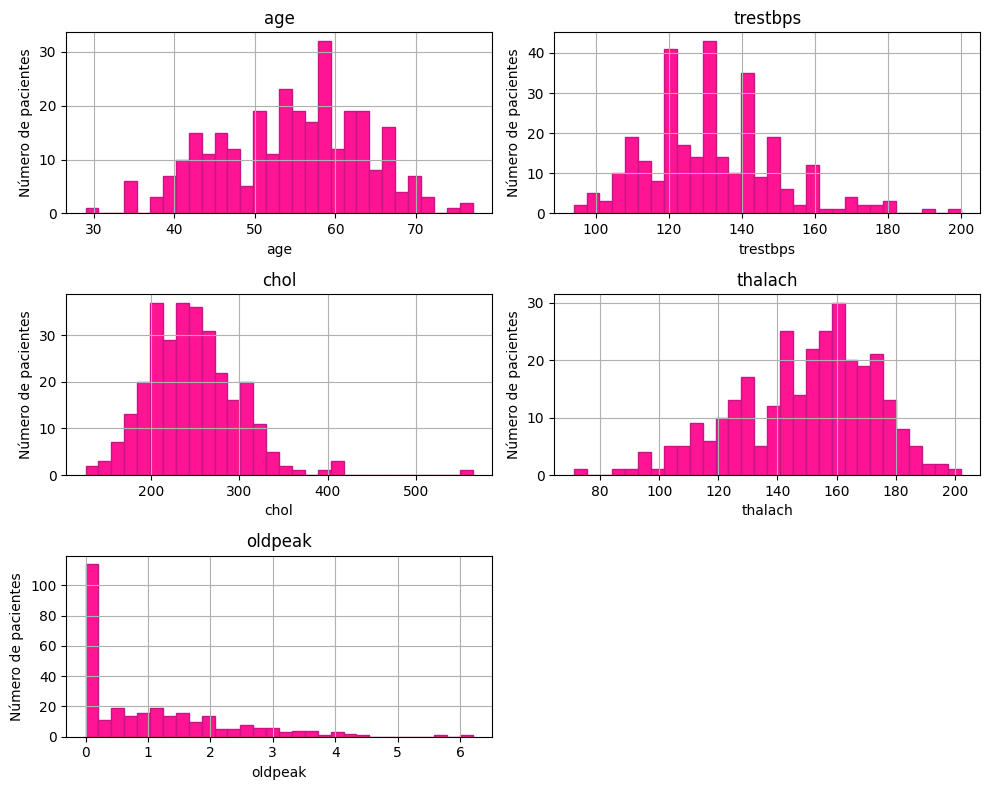

In [15]:
graficos_numericos = df[["age", "trestbps", "chol", "thalach", "oldpeak"]].hist(
    figsize=(10, 8), edgecolor='mediumvioletred', bins=30, color="deeppink")

for ax, col in zip(graficos_numericos.ravel(), colunas_numericas):
    ax.set_ylabel("Número de pacientes")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

<h5>Interpretação do gráfico</h5>
<p style="text-align: justify;">Os hitogramas mostram que uma grande parte da população estudada está entre 50 e 60 anos. As variáveis pressão arterial (trestbps) e colesterol (chol) apresentam maior concentração em faixas elevadas, além de alguns valores extremos, estes pouco observados. A frequência cardíaca máxima (thalach) possui distribuição aproximadamente simétrica, concentrando-se entre 140 e 180 bpm. já a varivel oldpeak apresenta grande assimetria à direita, com grande quantidade de pacientes possuindo valores próximos de zero e poucos indivíduos apresentando valores elevados.  </p>


<h4>Gráficos dos dados categóricos</h4>

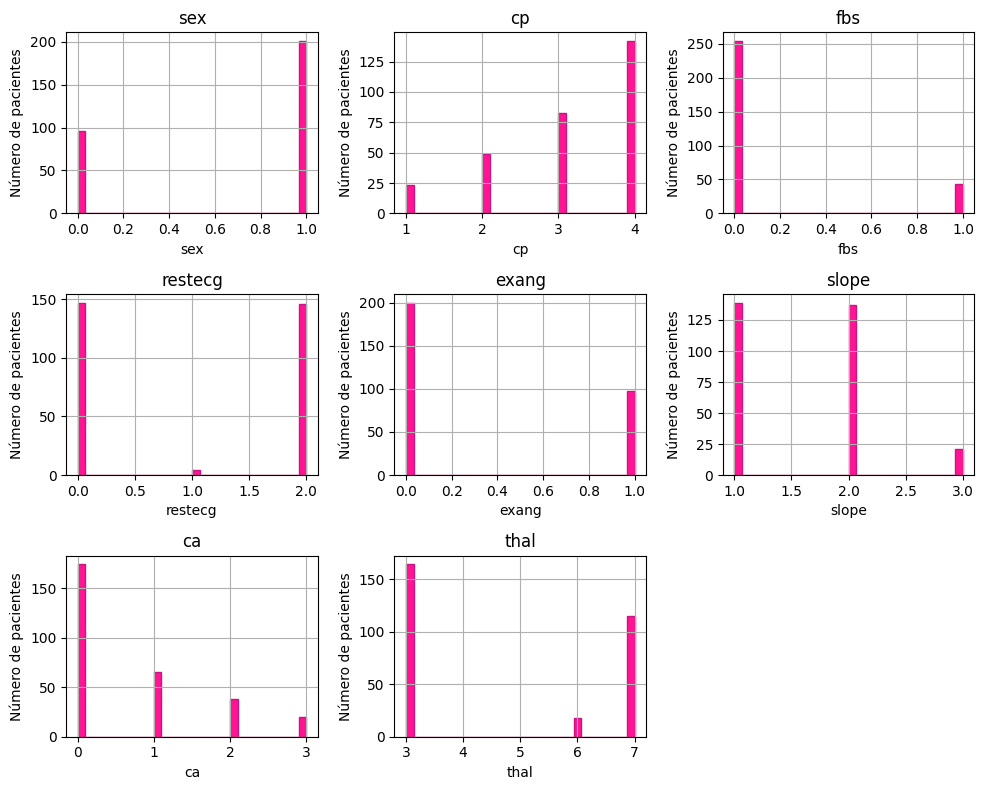

In [16]:
graficos_categoricos = df[["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]].hist(
    figsize=(10, 8), edgecolor='mediumvioletred', bins=30, color="deeppink")

for ax, col in zip(graficos_categoricos.ravel(), colunas_categoricas):
    ax.set_ylabel("Número de pacientes")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

<h5>Interpretação do gráfico</h5>
<p style="text-align: justify;">As variáveis categóricas apresentam distribuições desbalanceadas entre suas classes. Observa-se predominância de homens na variável sex, baixa ocorrência de glicemia elevada em fbs e maior concentração de pacientes sem angina induzida por exercício (exang). Nas variáveis ca e thal, algumas categorias concentram grande parte das observações, enquanto outras possuem poucos registros. Esses resultados indicam que certas características são muito mais frequentes na amostra.  </p>

<h3>Definindo o target e a métrica</h3>
<p style="text-align:justify">O target escolhido foi: Possui doença cardiaca?<br>
O target escolhido continha níveis que iam de 0 a 4. Contudo, foi escolhido agrupar os níveis de 1 a 4 em uma única classe positiva. Essa simplificação serve para facilitar a interpretação do problema. Desse modo, o target foi binarizado, o     0 = sem doença e o 1 = com doença<br>
Na célula abaixo, o target é binarizado, o balanceamento dos dados é verificado e representado por um gráfico.     </p>

target
0    160
1    137
Name: count, dtype: int64


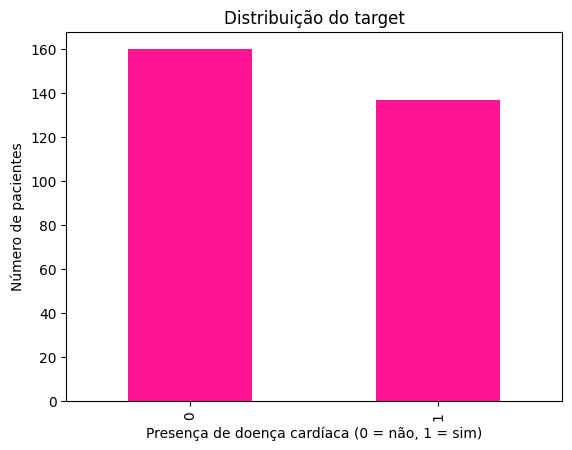

In [17]:

df["target"] = df["target"].apply(lambda x: 0 if x == 0 else 1)
print(df["target"].value_counts())

df["target"].value_counts().plot(kind="bar", color="deeppink")
plt.xlabel("Presença de doença cardíaca (0 = não, 1 = sim)")
plt.ylabel("Número de pacientes")
plt.title("Distribuição do target")
plt.show()

<p style="text-align:justify"> A distribuição das classes ficou em 54,15% como 0 (não possui doença) e 45,85% como 1(possui doença). Como as proporções das duas classes estão muito próximas, pode-se considerar a base de dados está relativamente balanceadas. <br>
   <p style="text-align:justify"> 
A métrica utilizada para avaliar o modelo será a da acurácia, pois essa métrica é boa para problemas de classificação em que as classes estão balanceadas e são categóricas. A acurácia mede a proporção entre as previsões corretas do modelo em relação aos total de exemplo usados. 
<p style="text-align:justify">
No entanto, a acurácia não diferencia os tipos de erro cometidos pelo modelo, tratando falsos positivos e falsos negativos com o mesmo peso. Por isso, seráusada também a matriz de confusão como métrica, já que um falso negativo é muito mais grave que um falso positivo e com ela é possível observar esses dois tipo de erros separadamente [5]. A matriz de confusão é de uma tabela de duas linhas e duas colunas (caso o problema de classificação seja binário), na qual as linhas representam as classes previstas, enquanto que as colunas representam as classes reais e os valores das células são as frequências de ocorrência das combinações previsto-real [8].
<p style="text-align:justify">
    
Assim, a combinação das duas métricas permite tanto uma visão geral rápida do desempenho (acurácia) quanto uma análise mais detalhada da natureza dos erros cometidos (matriz de confusão)</p>

<h3>Correlação entre os dados numéricos e categóricos e o target</h3>
<p style="text-align:justify">Nesse passo, serão feitos gráficos relacionando o target com os dados numéricos e categóricos. Essa relação irá ajudar a entender como esses atributos ajudam a separar as pessoas com doenças das que não possuem doença.  </p>

<h4>Dados numéricos</h4>

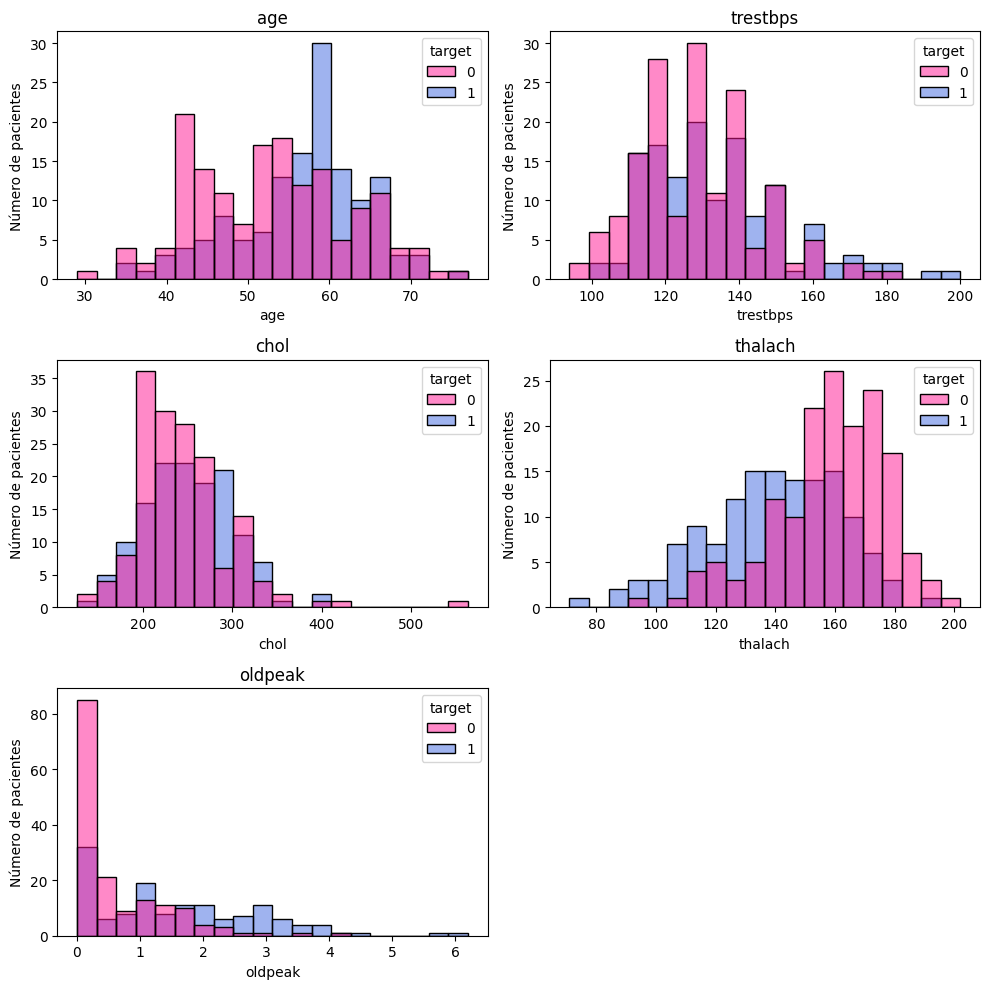

In [18]:

fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.ravel()

for i, col in enumerate(colunas_numericas):
    sns.histplot(data=df, x=col, hue="target", bins=20, ax=axes[i], palette=["deeppink", "royalblue"])
    axes[i].set_ylabel("Número de pacientes")
    axes[i].set_xlabel(col)
    axes[i].set_title(col)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

<h5>Box plot</h5>

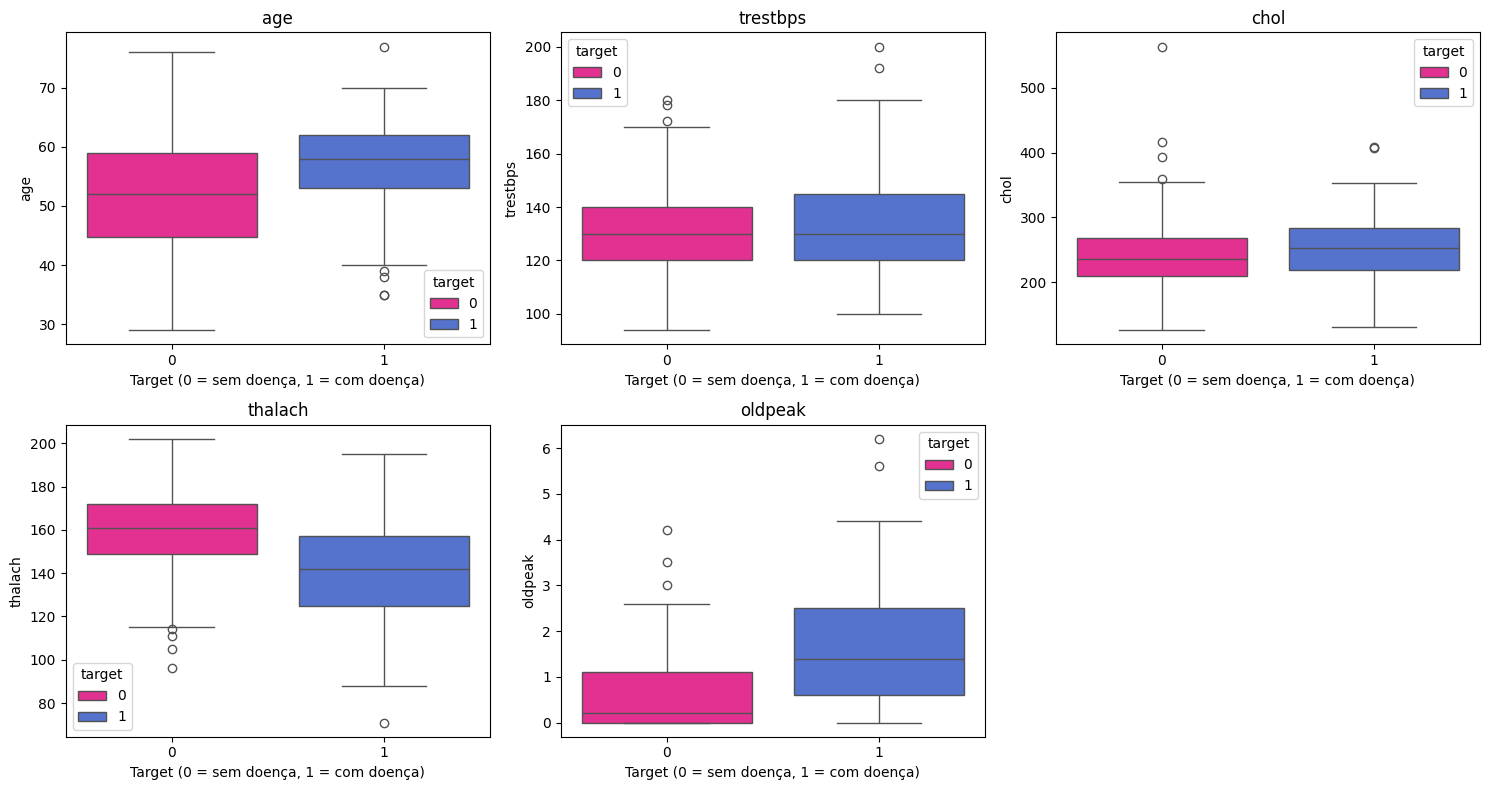

In [19]:


fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, col in enumerate(colunas_numericas):
    sns.boxplot(data=df, x="target", y=col, hue="target", ax=axes[i], palette=["deeppink", "royalblue"])
    axes[i].set_xlabel("Target (0 = sem doença, 1 = com doença)")
    axes[i].set_ylabel(col)
    axes[i].set_title(col)

fig.delaxes(axes[-1]) 
plt.tight_layout()
plt.show()

<h5>Interpretação do gráfico</h5>
<p style="text-align: justify;">Ao comparar as distribuições das variáveis numéricas em função do target, observa-se que age, trestbps e chol, isoladamente, não permitem distinguir de forma clara os pacientes com e sem doença cardíaca. Por outro lado, thalach e oldpeak demonstram diferenças mais evidentes entre os grupos. Pacientes sem doença cardíaca tendem a alcançar frequências cardíacas máximas mais elevadas (thalach), enquanto pacientes com doença apresentam valores mais altos de depressão do segmento ST (oldpeak). <br>
  <p style="text-align: justify;">  
A análise dos boxplots reforça esses resultados, mostrando ainda que indivíduos com doença cardíaca tendem a apresentar idade mais elevada, menor frequência cardíaca máxima atingida e maior variabilidade nos valores de oldpeak. As maiores diferenças foram observadas justamente nas variáveis thalach e oldpeak, indicando forte capacidade de discriminação entre as classes. Em contrapartida, trestbps e chol apresentam distribuições bastante semelhantes nos dois grupos, sugerindo menor contribuição individual para a identificação da doença cardíaca. Dessa forma, thalach e oldpeak destacam-se como atributos potencialmente importantes para a predição da presença de doença cardíaca.<br>
TAnto no box plot, quanto no histograma, existe a presença de outliers em algumas variáveis, valores que se afastam consideravelmente da tendência central dos dados, como os pontos isolados observados em chol, trestbps e oldpeak. Esses valores extremos podem impactar o desempenho do k-NN, já que o algoritmo se baseia no cálculo de distância entre os pacientes: um único atributo com valor muito distante da média pode distorcer a distância calculada, mesmo que os demais atributos daquele paciente sejam típicos. Essa observação reforça a importância da normalização, discutida mais adiante neste trabalho.</p>

<h4>Dados categóricos</h4>

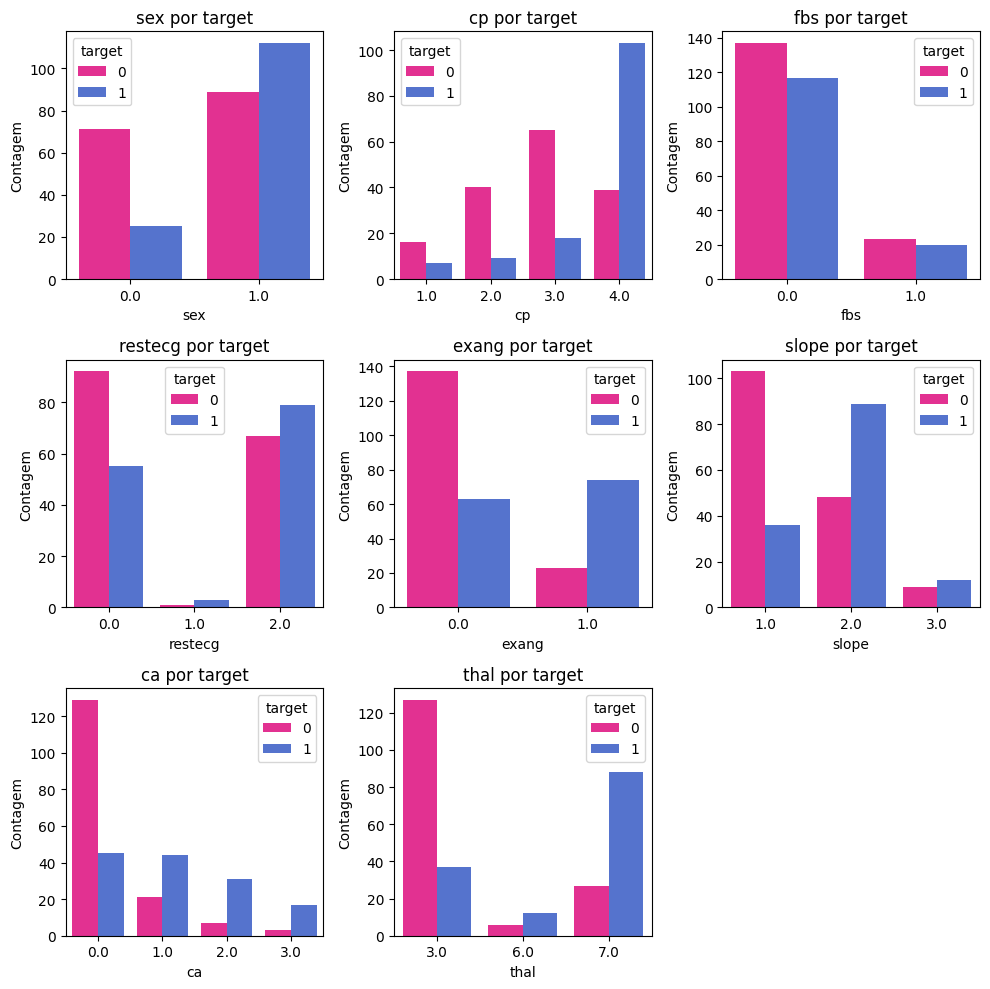

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas):
    sns.countplot(data=df, x=col, hue="target", ax=axes[i], palette=["deeppink", "royalblue"])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Contagem")
    axes[i].set_title(f"{col} por target")
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

<h5>Interpretação do gráfico</h5>
<p style="text-align: justify;">A análise das variáveis categóricas em função do target mostra que algumas características apresentam forte associação com a presença de doença cardíaca. As variáveis cp, exang, slope, ca e thal exibem diferenças expressivas entre pacientes com e sem doença, sugerindo elevado potencial preditivo. Em especial, ca e thal demonstram as separações mais evidentes entre as classes. Por outro lado, fbs apresenta distribuições muito semelhantes nos dois grupos, indicando menor capacidade de discriminação. Esses resultados sugerem que as variáveis categóricas podem contribuir significativamente para a predição da doença cardíaca, especialmente quando combinadas com atributos numéricos como thalach e oldpeak </p>

<h3>Matriz de correlação</h3>
<p style="text-align:justify">A matriz de correlação uma tabela que contém os coeficientes de correlação de diferentes variáveis. Ela mostra como todos os pares possíveis de valores em um conjunto de dados estão relacionados entre si. Os coeficientes de correlação variam de -1 a 1, onde valores próximos de 1 indicam correlação positiva forte, valores próximos de -1 indicam correlação negativa forte e valores próximos de 0 indicam pouca ou nenhuma correlação linear[6]. <br>
Nesse trabalho a matriz de correlação será usada para verificar a relação entre as variáveis e o target.</p>

In [21]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.092399,0.110471,0.290476,0.202644,0.132062,0.149917,-0.394563,0.096489,0.197123,0.159405,0.362210,0.126586,0.227075
sex,-0.092399,1.000000,0.008908,-0.066340,-0.198089,0.038850,0.033897,-0.060496,0.143581,0.106567,0.033345,0.091925,0.383652,0.278467
cp,0.110471,0.008908,1.000000,-0.036980,0.072088,-0.057663,0.063905,-0.339308,0.377525,0.203244,0.151079,0.235644,0.268500,0.408945
trestbps,0.290476,-0.066340,-0.036980,1.000000,0.131536,0.180860,0.149242,-0.049108,0.066691,0.191243,0.121172,0.097954,0.138183,0.153490
chol,0.202644,-0.198089,0.072088,0.131536,1.000000,0.012708,0.165046,-0.000075,0.059339,0.038596,-0.009215,0.115945,0.010859,0.080285
fbs,0.132062,0.038850,-0.057663,0.180860,0.012708,1.000000,0.068831,-0.007842,-0.000893,0.008311,0.047819,0.152086,0.062209,0.003167
restecg,0.149917,0.033897,0.063905,0.149242,0.165046,0.068831,1.000000,-0.072290,0.081874,0.113726,0.135141,0.129021,0.018795,0.166343
thalach,-0.394563,-0.060496,-0.339308,-0.049108,-0.000075,-0.007842,-0.072290,1.000000,-0.384368,-0.347640,-0.389307,-0.268727,-0.274831,-0.423817
exang,0.096489,0.143581,0.377525,0.066691,0.059339,-0.000893,0.081874,-0.384368,1.000000,0.289310,0.250572,0.148232,0.326927,0.421355
oldpeak,0.197123,0.106567,0.203244,0.191243,0.038596,0.008311,0.113726,-0.347640,0.289310,1.000000,0.579037,0.294452,0.344976,0.424052


<p style="text-align:justify"> Observando a coluna referente à variável target, nota-se que os atributos thal (0,53), ca (0,46), oldpeak (0,42), exang (0,42) e cp (0,41) apresentam as correlações positivas mais elevadas com o diagnóstico de doença cardíaca. Posteriormente essas variáveis serão usadas para análises.<br>
Essa relação irá ser verificada novamente posteriormente, visto que será feito um knn com os 8 atríbutos com mais relação com o target</p>

<h2>Split treino/teste, normalização, one-hot e ordinação</h2>
<p style="text-align: justify;""> A divisão do dataset entre conjuntos de treinamento e teste é fundamental para avaliar a capacidade de generalização do modelo, ou seja, seu desempenho em dados novos e não observados durante o treinamento. O conjunto de treinamento é utilizado para o aprendizado do modelo, enquanto o conjunto de teste permite avaliar seu desempenho de forma mais realista [2]. Neste trabalho, foram reservados 20% dos dados para teste e 80% dos dados para treino.<br>
<p style="text-align: justify;">
Neste trabalho, optou-se por utilizar uma única divisão estratificada entre os conjuntos de treino e teste, em vez de aplicar validação cruzada. Essa escolha foi feita considerando o caráter introdutório do projeto e o objetivo de analisar, de forma direta, o impacto de diferentes estratégias de pré-processamento, configurações do k-NN sobre um conjunto de teste mantido separado, diferentes formas de codificação dos atributos categóricos e técnicas de normalizaçã.<br>
<p style="text-align: justify;">
Nesta etapa, os dados também foram normalizados utilizando duas abordagens: padronização pela média e desvio padrão (Standard Scaling) e normalização pelo valor mínimo e máximo (Min-Max Scaling). Esse procedimento é especialmente importante para o kNN, pois o algoritmo baseia suas previsões na distância entre os exemplos. Caso os atributos possuam escalas muito diferentes, variáveis com valores numericamente maiores podem exercer influência desproporcional no cálculo das distâncias e, consequentemente, nas previsões do modelo.<br>
<p style="text-align: justify;">
Além disso, como o kNN requer entradas numéricas, os atributos categóricos precisaram ser codificados. No Ordinal Encoding, cada categoria é representada por um número inteiro, preservando uma possível relação de ordem entre elas. Já o One-Hot Encoding cria uma variável binária para cada categoria, indicando sua presença (1) ou ausência (0), sem estabelecer qualquer ordem entre os valores [7]. O Ordinal Encoding é adequado para atributos que possuem uma ordenação natural, como slope, mas pode introduzir relações de distância artificiais em variáveis sem ordem, como cp. Por outro lado, o One-Hot Encoding evita esse problema, porém aumenta a dimensionalidade do conjunto de dados, o que pode impactar negativamente o desempenho do kNN em bases menores. Como não existe uma escolha universalmente superior para esse caso, ambas as abordagens serão avaliadas e comparadas posteriormente.<br>

Também foi usada uma semente aleatória para garantur a reprodutibilidade e simplificação da interpretação dos resultados.
<p style="text-align: justify;">
    Nas células abaixo, é definido a parte dos dados reservada para treino e teste e a semente aleatória, é feita a normaização seguindo os métodos já citados acima dos dados numéricos e enconding dos dados categóricos seguindo os métodos também já citados acima.</p>

separação dos dados entre treino e teste

In [22]:


TAMANHO_TESTE = 0.2
indices = df.index
indices_treino, indices_teste = train_test_split(
    indices, test_size=TAMANHO_TESTE, random_state=42, stratify=df["target"]
)

df_treino = df.loc[indices_treino]
df_teste = df.loc[indices_teste]

print(df_treino["target"].value_counts(normalize=True))
print(df_teste["target"].value_counts(normalize=True))



target
0    0.540084
1    0.459916
Name: proportion, dtype: float64
target
0    0.533333
1    0.466667
Name: proportion, dtype: float64


Normalizando os dados numéricos usando os métodos MinMaxScaler e StandardScaler

In [23]:
#normalizando

#normalização média
scaler = StandardScaler()

scaler.fit(df_treino[colunas_numericas])

df_treino_normalizado = df_treino.copy()
df_teste_normalizado = df_teste.copy()

df_treino_normalizado[colunas_numericas] = scaler.transform(df_treino[colunas_numericas])
df_teste_normalizado[colunas_numericas] = scaler.transform(df_teste[colunas_numericas])

#normalização minimo maximo
scaler_minmax = MinMaxScaler()

scaler_minmax.fit(df_treino[colunas_numericas])

df_treino_minmax = df_treino.copy()
df_teste_minmax = df_teste.copy()

df_treino_minmax[colunas_numericas] = scaler_minmax.transform(df_treino[colunas_numericas])
df_teste_minmax[colunas_numericas] = scaler_minmax.transform(df_teste[colunas_numericas])

Codificando os dados categóricos utilizando one-hot e juntando os dados categóricos one-hot com os numéricos(MinMax, StandardScaler e sem normalizar)

In [24]:
#one-hot


encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoder.fit(df_treino[colunas_categoricas])

treino_encoded = encoder.transform(df_treino[colunas_categoricas])
teste_encoded = encoder.transform(df_teste[colunas_categoricas])

nomes_colunas = encoder.get_feature_names_out(colunas_categoricas)

df_treino_encoded = pd.DataFrame(treino_encoded, columns=nomes_colunas, index=df_treino.index)
df_teste_encoded = pd.DataFrame(teste_encoded, columns=nomes_colunas, index=df_teste.index)

# Juntando tudo
#normalizado
df_treino_final_norm = pd.concat(
    [df_treino_normalizado[colunas_numericas], df_treino_encoded, df_treino["target"]], axis=1
)
df_teste_final_norm = pd.concat(
    [df_teste_normalizado[colunas_numericas], df_teste_encoded, df_teste["target"]], axis=1
)
#minmax
df_treino_final_minmax = pd.concat(
    [df_treino_minmax[colunas_numericas], df_treino_encoded, df_treino["target"]], axis=1
)
df_teste_final_minmax = pd.concat(
    [df_teste_minmax[colunas_numericas], df_teste_encoded, df_teste["target"]], axis=1
)
#sem modificação
df_treino_final = pd.concat(
    [df_treino[colunas_numericas], df_treino_encoded, df_treino["target"]], axis=1
)
df_teste_final = pd.concat(
    [df_teste[colunas_numericas], df_teste_encoded, df_teste["target"]], axis=1
)

Codificando os dados categóricos utilizando ordinal juntando os dados categóricos ordinais com os numéricos(MinMax, StandardScaler e sem normalizar)

In [25]:
#ordinal


colunas_categoricas = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

encoder_ordinal = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
encoder_ordinal.fit(df_treino[colunas_categoricas])

treino_ordinal = encoder_ordinal.transform(df_treino[colunas_categoricas])
teste_ordinal = encoder_ordinal.transform(df_teste[colunas_categoricas])

df_treino_ordinal_encoded = pd.DataFrame(treino_ordinal, columns=colunas_categoricas, index=df_treino.index)
df_teste_ordinal_encoded = pd.DataFrame(teste_ordinal, columns=colunas_categoricas, index=df_teste.index)

# juntando com os numéricos normalizados + target (igual fizemos com o one-hot)
df_treino_final_ordinal_norm = pd.concat(
    [df_treino_normalizado[colunas_numericas], df_treino_ordinal_encoded, df_treino["target"]], axis=1
)
df_teste_final_ordinal_norm = pd.concat(
    [df_teste_normalizado[colunas_numericas], df_teste_ordinal_encoded, df_teste["target"]], axis=1
)

df_treino_final_ordinal_minmax = pd.concat(
    [df_treino_minmax[colunas_numericas], df_treino_ordinal_encoded, df_treino["target"]], axis=1
)
df_teste_final__ordinal_minmax = pd.concat(
    [df_teste_minmax[colunas_numericas], df_teste_ordinal_encoded, df_teste["target"]], axis=1
)

#sem modificação
df_treino_final_ordinal = pd.concat(
    [df_treino[colunas_numericas], df_treino_ordinal_encoded, df_treino["target"]], axis=1
)
df_teste_final_ordinal = pd.concat(
    [df_teste[colunas_numericas], df_teste_ordinal_encoded, df_teste["target"]], axis=1
)

<h2>Modelo baseline</h2>
<p style="text-align: justify;">O baseline serve como paramêtro para comparação: um modelo simples (DummyClassifier com estratégia most_frequent, que sempre prevê a classe mais comum) permite verificar se o kNN está realmente aprendendo algo útil dos dados, ou apenas repetindo o óbvio. <br>
Nesse caso, o baseline foi feito com os dados sem normalização e codificação, já que independente do tipo de normalização ele irá considerar a moda dos dados. Ele será posteriormente comparado com os modelos knn com normalização e sem normalizar.</p>

Acurácia do baseline: 0.5333333333333333


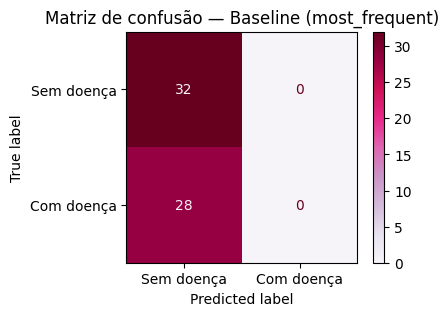

In [28]:



X_treino = df_treino_final.drop(columns=["target"])
y_treino = df_treino_final["target"]

X_teste = df_teste_final.drop(columns=["target"])
y_teste = df_teste_final["target"]

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_treino, y_treino)

y_previsto_baseline = baseline.predict(X_teste)

acuracia_baseline = accuracy_score(y_teste, y_previsto_baseline)
print(f"Acurácia do baseline: {acuracia_baseline:}")
fig, ax = plt.subplots(figsize=(4, 3))
matriz_confusao = confusion_matrix(y_teste, y_previsto_baseline)
ConfusionMatrixDisplay(matriz_confusao, display_labels=["Sem doença", "Com doença"]).plot(cmap="PuRd", ax=ax)
plt.title("Matriz de confusão — Baseline (most_frequent)")
plt.show()

<p style="text-align: justify;">Nesse caso, 53% de acurácia parece um resultado mediano, mas na verdade só reflete a proporção de pacientes sem doença no conjunto de teste (32 de 60), já que o modelo está sempre prevendo essa classe.
Já a matriz de confusão revela o que a acurácia esconde: o baseline acertou os 32 casos de pacientes sem doença, mas errou todos os 28 casos de pacientes com doença. Isso confirma que o modelo não identifica nenhum paciente doente, apenas aposta sempre na classe majoritária.<br>
Ressalta-se que os falsos negativos são dados extremamente alarmantes nesse caso, já que isso pode causar sérios problemas na saúde do paciente.</p>

<h2>Fixando o encoding e aplicando o knn<h2>
<h3>Por que usar o kNN</h3>
<p style="text-align: justify;">
O k-vizinhos mais próximos (kNN) é o algoritmo escolhido para esta tarefa.
Ele classifica um novo paciente observando os <code>k</code> pacientes mais
parecidos com ele no conjunto de treino (com base na distância entre os
atributos) e atribuindo a classe mais frequente entre esses vizinhos. É um
algoritmo simples e intuitivo, mas sensível à escala dos atributos e à forma
como os dados categóricos são representados, por isso serão testados diferentes
estratégias de normalização e codificação ao longo deste notebook.
</p>

<h3>O que o código faz</h3>

<p style="text-align: justify;">
Para isolar o efeito da normalização, foi fixado o encoding  e os
hiperparâmetros do kNN (<code>n_neighbors=5</code>, resto padrão), e
treinado o modelo em três versões dos dados: sem normalizar, normalizada
com <code>MinMaxScaler</code> e normalizada com <code>StandardScaler</code>.
Para cada versão, foi feito o cálculo da acurácia no conjunto de teste e gerado a
matriz de confusão, que mostra os acertos e erros por classe. Ao final,
foi comparado a acurácia das três versões entre si e com o baseline, em um
gráfico de barras, para identificar qual estratégia de normalização
produziu o melhor resultado.
</p>



 Sem normalizar ---
Acurácia: 0.6833


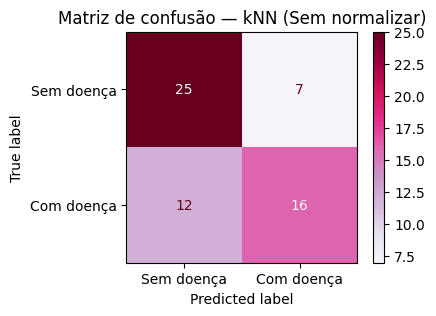

 MinMax ---
Acurácia: 0.8500


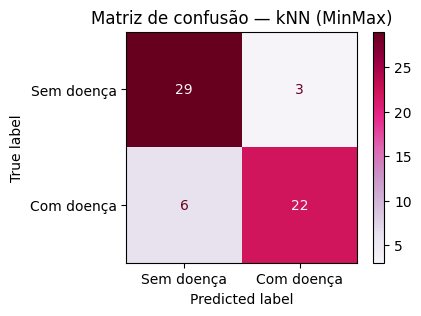

 StandardScaler ---
Acurácia: 0.8667


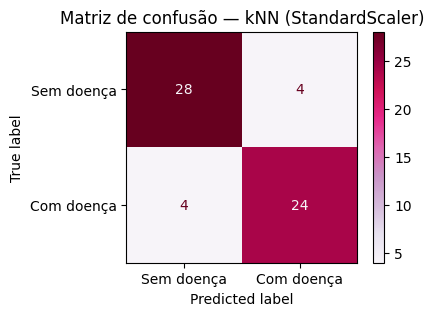

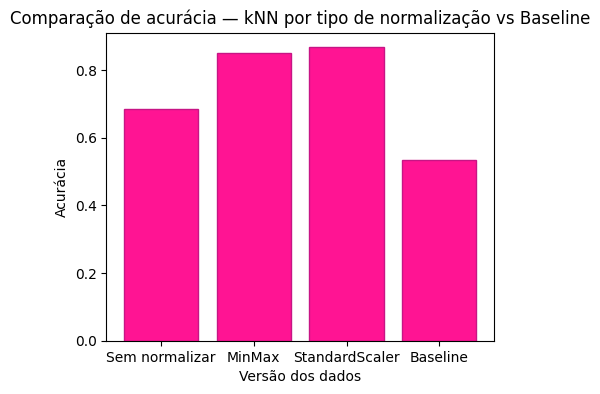

In [20]:


NUM_VIZINHOS = 5

versoes = {
    "Sem normalizar": (df_treino_final, df_teste_final),
    "MinMax": (df_treino_final_minmax, df_teste_final_minmax),
    "StandardScaler": (df_treino_final_norm, df_teste_final_norm),
}

resultados = {}

for nome, (treino, teste) in versoes.items():
    X_treino = treino.drop(columns=["target"])
    y_treino = treino["target"]
    X_teste = teste.drop(columns=["target"])
    y_teste = teste["target"]

    modelo_knn = KNeighborsClassifier(n_neighbors=NUM_VIZINHOS)
    modelo_knn.fit(X_treino, y_treino)

    y_previsto = modelo_knn.predict(X_teste)
    acuracia = accuracy_score(y_teste, y_previsto)
    resultados[nome] = acuracia

    print(f" {nome} ---")
    print(f"Acurácia: {acuracia:.4f}")
    fig, ax = plt.subplots(figsize=(4, 3))
    matriz_confusao = confusion_matrix(y_teste, y_previsto)
    ConfusionMatrixDisplay(matriz_confusao, display_labels=["Sem doença", "Com doença"]).plot(cmap="PuRd",ax=ax)
    plt.title(f"Matriz de confusão — kNN ({nome})")
    plt.show()

resultados["Baseline"] = acuracia_baseline

plt.figure(figsize=(5, 4))
plt.bar(resultados.keys(), resultados.values(), color="deeppink", edgecolor="mediumvioletred")
plt.ylabel("Acurácia")
plt.xlabel("Versão dos dados")
plt.title("Comparação de acurácia — kNN por tipo de normalização vs Baseline")
plt.show()

<h3>Discussão sobre os resultados obtidos</h3>
<p style="text-align: justify;">
Os resultados mostram que a normalização dos dados teve impacto significativo no desempenho do algoritmo kNN. Sem normalização, o modelo alcançou uma acurácia de aproximadamente 0,68, apresentando 25 verdadeiros negativos, 16 verdadeiros positivos, 7 falsos positivos e 12 falsos negativos. Esse foi o pior desempenho entre todas as versões avaliadas, mas ainda sim foi melhor do que os resultados obtidos com o modelo baseline.<br>

Ao aplicar a normalização MinMaxScaler, a acurácia aumentou para 0,85, indicando uma melhora considerável na capacidade de classificação do modelo. A matriz de confusão mostrou 29 verdadeiros negativos e 22 verdadeiros positivos, além da redução dos erros para apenas 3 falsos positivos e 6 falsos negativos.<br>

O melhor resultado foi obtido com o StandardScaler, que alcançou uma acurácia de aproximadamente 0,87. Nessa configuração, o modelo apresentou 28 verdadeiros negativos e 24 verdadeiros positivos, cometendo somente 4 falsos positivos e 4 falsos negativos, uma melhora extremamnete válida, visto que falsos negativos são um grande sinal de alerta nesse caso. Além de possuir a maior acurácia, essa versão também apresentou a distribuição mais equilibrada de erros entre as duas classes.<br>

Comparando os resultados com o modelo baseline, cuja acurácia foi de aproximadamente 0,53, observa-se que todas as versões do kNN obtiveram desempenho superior. Entretanto, a diferença foi muito mais expressiva quando os dados passaram por algum processo de normalização. Isso ocorre porque o kNN utiliza medidas de distância para classificar as amostras, tornando-se sensível a variáveis que possuem escalas diferentes.
</p>

<h3>Variando o encoding e aplicando o kNN</h3>
<p style="text-align: justify;">
Na etapa anterior, foi comparado o desempenho do kNN utilizando três estratégias de normalização (sem normalizar, MinMaxScaler e StandardScaler), mantendo fixos o encoding e os hiperparâmetros do modelo. O StandardScaler apresentou a melhor acurácia entre as três (0.87), sendo selecionado como a estratégia de normalização a ser utilizada daqui em diante.

Agora, será isolado o efeito da estratégia de codificação dos atributos categóricos, fixando o StandardScaler como normalização e comparando o desempenho do kNN utilizando one-hot encoding versus ordinal encoding.<br>
</p>
<h4>Por que o StandardScaler foi escolhido</h4>
<p style="text-align: justify;">
O StandardScaler obteve acurácia ligeiramente superior ao MinMaxScaler (0.87 contra 0.85). Embora a diferença seja pequena, ela é consistente com o que foi observado na análise exploratória: alguns atributos numéricos (como chol e oldpeak) apresentam outliers. O MinMaxScaler é mais sensível a esses valores extremos, já que utiliza apenas o mínimo e o máximo para definir a escala, um único valor muito distante dos demais pode comprimir a faixa útil de todos os outros valores. O StandardScaler, por utilizar média e desvio padrão, é menos afetado por essa distorção, o que pode explicar seu desempenho ligeiramente melhor neste dataset.
</p>

One-hot
Acurácia: 0.87


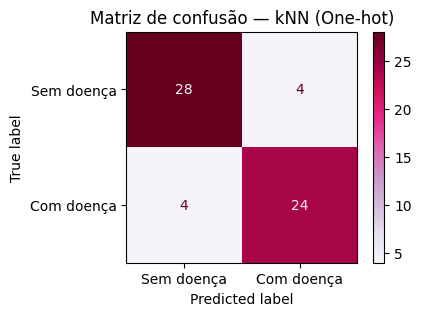

Ordinal
Acurácia: 0.82


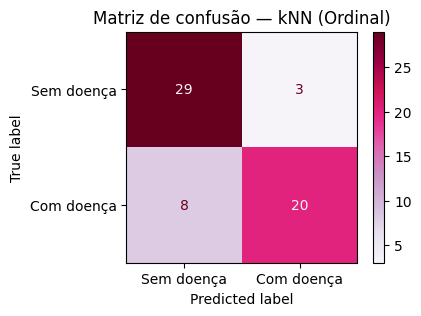

In [21]:
versoes_encoding = {
    "One-hot": (df_treino_final_norm, df_teste_final_norm),
    "Ordinal": (df_treino_final_ordinal_norm, df_teste_final_ordinal_norm),
}

resultados_encoding = {}

for nome, (treino, teste) in versoes_encoding.items():
    X_treino = treino.drop(columns=["target"])
    y_treino = treino["target"]
    X_teste = teste.drop(columns=["target"])
    y_teste = teste["target"]

    modelo_knn = KNeighborsClassifier(n_neighbors=NUM_VIZINHOS)
    modelo_knn.fit(X_treino, y_treino)

    y_previsto = modelo_knn.predict(X_teste)
    acuracia = accuracy_score(y_teste, y_previsto)
    resultados_encoding[nome] = acuracia

    print(f"{nome}")
    print(f"Acurácia: {acuracia:.2f}")
    fig, ax = plt.subplots(figsize=(4, 3))
    matriz_confusao = confusion_matrix(y_teste, y_previsto)
    ConfusionMatrixDisplay(matriz_confusao, display_labels=["Sem doença", "Com doença"]).plot(cmap="PuRd",ax=ax)
    plt.title(f"Matriz de confusão — kNN ({nome})")
    plt.show()

<H3>Discussão sobre os resultados</H3>
<p style="text-align: justify;">Comparando os métodos de codificação, o One-Hot Encoding apresentou melhor desempenho, alcançando uma acurácia de 87%, enquanto o Ordinal Encoding obteve 82%. Além da maior acurácia, o One-Hot produziu uma matriz de confusão mais equilibrada, reduzindo pela metade o número de falsos negativos (4 contra 8). Como o objetivo é identificar corretamente pacientes com doença, a redução dos falsos negativos torna o One-Hot Encoding a alternativa mais adequada para este problema. Os resultados sugerem que representar as categorias sem impor uma ordem artificial permitiu ao algoritmo kNN capturar melhor os padrões presentes nos dados.</p>

<h2>Variação dos hiperparâmetros</h2>
<p style="text-align: justify;">Os hiperparâmetro são variáveis de configuração externa definidas antes do início do treinamneto de um modelo. O ajuste de hiperparâmetros é importante porque estabelece as bases para a estrutura, a eficiência do treinamento e o desempenho de um modelo<br>
Ao variar o número de vizinhos é variado o número de dados próximos ao qual o modelo se basea para gerar uma resposta.<br>
Ao variar a distancia, a precisão do modelo, a sua sensibilidade a ruídos e a forma como as fronteiras de decisão são desenhadas  são afetadas. <strong>A Distância Euclidiana</strong>: É a linha reta entre dois pontos. <strong>Distância de Manhattan</strong>: Mede a distância seguindo eixos perpendiculares. <strong>Distância de Chebyshev</strong>: Calcula a distância entre dois pontos como a maior diferença absoluta entre suas coordenadas correspondentes em qualquer dimensão [3].
<br>
O weights controla como os vizinhos irão contribuir para a decisão final de classificação. <strong>Uniform</strong>: todos os k vizinhos têm peso igual na votação, independentemente da distância. <strong>Distance</strong>: os vizinhos mais próximos têm peso maior na votação do que os mais distantes<br>
O código abaixo faz a variação dos hiperparâmetros e gera uma tabela que mostra a acurácia de cada teste. Não é feita a matriz de confusão de cada teste individual, já que isso poderia sobrecarregar o sistema e dificultar a leitura do notebook. Devido à isso, foi optado por realizar as matrizes de confusão das combinações que apresentaram maior acurácia.</p>

In [22]:
valores_k = [1, 3, 5, 7, 9, 11, 15, 21]
metricas= ['euclidean', 'manhattan', 'chebyshev']
weight=['uniform', 'distance']
resultados = []

X_treino = df_treino_final_norm.drop(columns=["target"])
y_treino = df_treino_final_norm["target"]
X_teste = df_teste_final_norm.drop(columns=["target"])
y_teste = df_teste_final_norm["target"]

for w in weight:
    for metrica in metricas:
        for k in valores_k:
            modelo_knn = KNeighborsClassifier(n_neighbors=k, metric=metrica, weights=w)
            modelo_knn.fit(X_treino, y_treino)
            y_previsto = modelo_knn.predict(X_teste)
            
            acuracia = accuracy_score(y_teste, y_previsto)
            
            resultados.append({
                "weights": w,
                "metrica":metrica,
                "n_neighbors": k,
                "acuracia": accuracy_score(y_teste, y_previsto),
            })
            

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values("acuracia", ascending=False)
df_resultados

,weights,metrica,n_neighbors,acuracia
3,uniform,euclidean,7,0.900000
27,distance,euclidean,7,0.900000
2,uniform,euclidean,5,0.866667
0,uniform,euclidean,1,0.866667
5,uniform,euclidean,11,0.866667
15,uniform,manhattan,21,0.866667
28,distance,euclidean,9,0.866667
4,uniform,euclidean,9,0.866667
26,distance,euclidean,5,0.866667
24,distance,euclidean,1,0.866667


Escolha de modelos para análise detalhada

<p style="text-align: justify;">Depois de testar todas as 48 combinações de hiperparâmetros, foram escolhidas 4 para olhar mais de perto com a matriz de confusão, em vez de gerar isso para todas:<br>
    
euclidean, k=7, weights=uniform: melhor combinação geral.

euclidean, k=7, weights=distance: mesma métrica e k da melhor, só mudando o peso, mostra se ponderar por distância faz diferença.

manhattan, k=21, weights=uniform: melhor resultado com manhattan, com um k bem maior.

chebyshev, k=21, weights=uniform: melhor resultado com chebyshev, incluído por ter sido a métrica com pior desempenho geral.

O código abaixo treina cada um, calcula a acurácia novamente e gera a matriz de confusão, pra comparar não só o desempenho geral mas como cada modelo se sai especificamente identificando pacientes com doença.</p>

Selecionado por ser: melhor combinação geral entre todas as testadas
k=7, métrica=euclidean, weights=uniform, acurácia=0.90


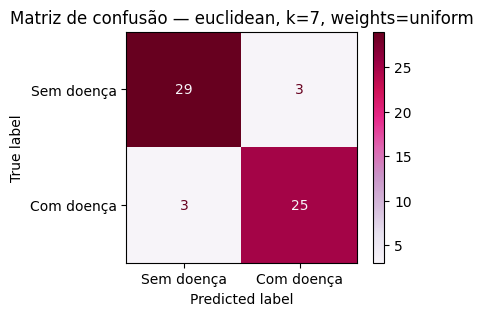

Selecionado por ser: mesma métrica e k da melhor combinação, mas com weight='distance' — permite comparar diretamente o efeito da ponderação por distância
k=7, métrica=euclidean, weights=distance, acurácia=0.90


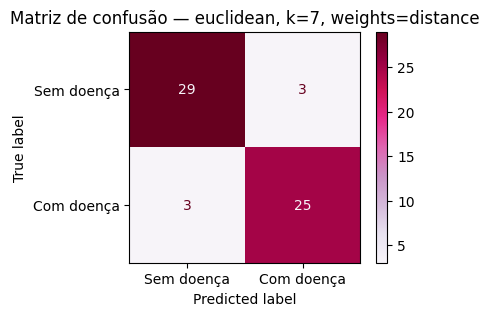

Selecionado por ser: melhor resultado obtido com a distância manhattan
k=21, métrica=manhattan, weights=uniform, acurácia=0.87


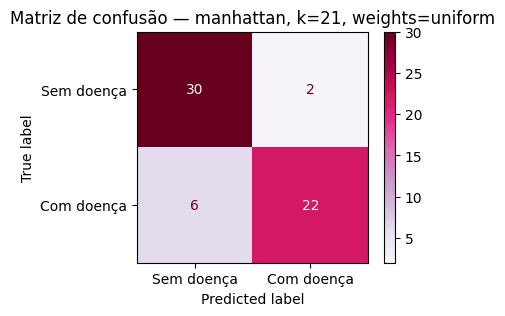

Selecionado por ser: melhor resultado obtido com a distância chebyshev, incluído para ilustrar que essa métrica teve desempenho inferior às demais neste dataset
k=21, métrica=chebyshev, weights=uniform, acurácia=0.78


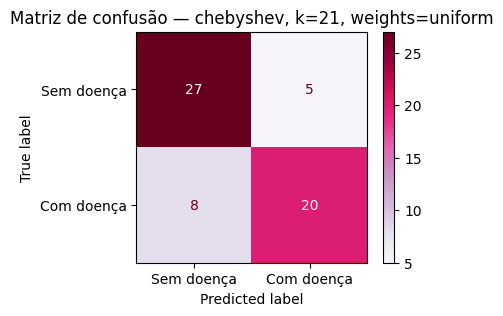

In [23]:
modelos_selecionados = [
    {"k": 7, "metrica": "euclidean", "weights": "uniform",
     "motivo": "melhor combinação geral entre todas as testadas"},
    {"k": 7, "metrica": "euclidean", "weights": "distance",
     "motivo": "mesma métrica e k da melhor combinação, mas com weight='distance' — permite comparar diretamente o efeito da ponderação por distância"},
    {"k": 21, "metrica": "manhattan", "weights": "uniform",
     "motivo": "melhor resultado obtido com a distância manhattan"},
    {"k": 21, "metrica": "chebyshev", "weights": "uniform",
     "motivo": "melhor resultado obtido com a distância chebyshev, incluído para ilustrar que essa métrica teve desempenho inferior às demais neste dataset"},
]

for modelo_info in modelos_selecionados:
    modelo_knn = KNeighborsClassifier(
        n_neighbors=modelo_info["k"],
        metric=modelo_info["metrica"],
        weights=modelo_info["weights"]
    )
    modelo_knn.fit(X_treino, y_treino)
    y_previsto = modelo_knn.predict(X_teste)

    acuracia = accuracy_score(y_teste, y_previsto)

    print(f"Selecionado por ser: {modelo_info['motivo']}")
    print(f"k={modelo_info['k']}, métrica={modelo_info['metrica']}, weights={modelo_info['weights']}, acurácia={acuracia:.2f}")
    fig, ax = plt.subplots(figsize=(4, 3))
    matriz_confusao = confusion_matrix(y_teste, y_previsto)
    ConfusionMatrixDisplay(matriz_confusao, display_labels=["Sem doença", "Com doença"]).plot(cmap="PuRd", ax=ax)
    plt.title(f"Matriz de confusão — {modelo_info['metrica']}, k={modelo_info['k']}, weights={modelo_info['weights']}")
    plt.show()

<h2>Escolha do melhor modelo com variação do hiperparâmetro e interpretação das matrizes de confusão</h2>
<h3>Declaração do modelo final</h3>

<p style="text-align: justify;">
O modelo final deste trabalho é o k-NN com codificação one-hot para os
atributos categóricos, normalização StandardScaler para os atributos
numéricos, <strong>k=7, distância euclidiana e weights=uniform</strong>,
escolhido por apresentar a maior acurácia (0.90) entre as 48 combinações
de hiperparâmetros testadas, além do menor número de falsos negativos
entre as combinações comparadas.
</p>

<h3>Análise das matrizes de confusão</h3>

<p style="text-align: justify;">
<strong>euclidean, k=7, weights=uniform (modelo final)</strong> — 29
verdadeiros negativos, 3 falsos positivos, 3 falsos negativos e 25
verdadeiros positivos. Um ponto que vale destacar é o número baixo de
falsos negativos (apenas 3 em 28 pacientes com doença), ou seja, o
modelo deixou passar poucos casos reais de doença cardíaca, o que é
desejável num contexto médico, onde não identificar um
paciente doente tende a ser mais grave do que gerar um alarme falso.
</p>

<p style="text-align: justify;">
<strong>euclidean, k=7, weights=distance</strong> — matriz de confusão
idêntica à anterior (29, 3, 3, 25). Isso indica que, nesse ponto
específico do espaço de hiperparâmetros, ponderar os vizinhos pela
distância não alterou nenhuma classificação em relação a tratá-los
igualmente. Por isso, optamos por manter <code>weights=uniform</code>,
por ser a versão mais simples entre as duas com desempenho idêntico.
</p>

<p style="text-align: justify;">
<strong>manhattan, k=21, weights=uniform</strong> — 30 verdadeiros
negativos, 2 falsos positivos, 8 falsos negativos e 22 verdadeiros
positivos. Apesar de ter o menor número de falsos positivos entre as
quatro combinações, essa versão teve 8 falsos negativos , mais que o
dobro do modelo final, deixando passar uma quantidade maior de
pacientes com doença não identificados, algo bem grave.
</p>

<p style="text-align: justify;">
<strong>chebyshev, k=21, weights=uniform</strong> — 27 verdadeiros
negativos, 5 falsos positivos, 8 falsos negativos e 20 verdadeiros
positivos. Foi a combinação com pior desempenho entre as quatro, tanto
em falsos positivos quanto em falsos negativos.
</p>

<h3>Por que a distância euclidiana teve o melhor desempenho</h3>

<p style="text-align: justify;">
As combinações com manhattan e chebyshev tiveram 8 falsos negativos
cada, mais que o dobro dos 3 falsos negativos do modelo final. Essa
diferença faz sentido considerando a natureza dos dados de entrada, que
combinam atributos numéricos contínuos (padronizados) com atributos
categóricos codificados em one-hot (binários, 0 ou 1, e em maior
número, já que cada categoria vira uma coluna própria).
</p>

<p style="text-align: justify;">
A distância de Chebyshev considera apenas a maior diferença entre as
coordenadas, ignorando as demais — em um espaço com muitas colunas
binárias, isso pode fazer a distância ser dominada por poucas
dimensões, desconsiderando informação relevante espalhada pelas outras
colunas. Já a distância euclidiana soma a contribuição de todas as
dimensões (ao quadrado), distribuindo o peso de forma mais equilibrada
entre os atributos numéricos e as diversas colunas binárias geradas
pelo one-hot. Isso provavelmente explica por que a euclidiana conseguiu
aproveitar melhor a informação combinada dos dois tipos de atributo,
resultando em menos falsos negativos.
</p>

<h3>Comparação com o baseline</h3>

<p style="text-align: justify;">
Todos os quatro modelos analisados superam com folga o baseline
(acurácia de 0.53), que classificava todos os pacientes como "sem
doença" e, por isso, tinha 28 falsos negativos — o pior cenário
possível, já que nenhum paciente doente era identificado.
</p>



<h2>Fazendo o Knn com os atríbutos que possuem maior afinidade com o target</h2>

<p style="text-align: justify;">
Também será avaliado um modelo k-NN utilizando apenas os atributos mais relacionados ao target. A ideia é investigar se concentrar a análise nas variáveis mais relevantes pode melhorar a capacidade de classificação do modelo, reduzindo a influência de atributos que contribuem pouco para a previsão.
</p>

<p style="text-align: justify;">
Nas células abaixo, será calculada novamente a afinidade dos atributos, já com os numéricos normalizados e os categóricos em one-hot. Após essa etapa será escolhido os 8 atributos mais relacionados (número arbitráriamente escolhido) e o Knn será treinado, utilizando os melhores hiperparâmetros identificados durante a variação dos hiperparâmetros. Também será comparado com o modelo com os atributos mais relacionados com o modelo com todos os atributos.
</p>

calculando a afinidade com o target

In [24]:
correlacao_com_target = df_treino_final_norm.corr()["target"].drop("target")
correlacao_com_target = correlacao_com_target.sort_values(key=abs, ascending=False)
correlacao_com_target

thal_3.0      -0.525092
cp_4.0         0.519082
thal_7.0       0.489028
ca_0.0        -0.437387
oldpeak        0.433589
slope_1.0     -0.397013
exang_1.0      0.396650
exang_0.0     -0.396650
thalach       -0.374239
slope_2.0      0.353672
cp_3.0        -0.334918
ca_2.0         0.254733
cp_2.0        -0.249012
sex_0.0       -0.242475
sex_1.0        0.242475
ca_1.0         0.214677
age            0.198975
restecg_0.0   -0.181683
restecg_2.0    0.171254
ca_3.0         0.163791
trestbps       0.163168
thal_6.0       0.089125
slope_3.0      0.089125
cp_1.0        -0.072814
chol           0.066131
restecg_1.0    0.046971
fbs_0.0       -0.013638
fbs_1.0        0.013638
Name: target, dtype: float64

Escolhendo quais atributos manter

In [25]:
correlacao_com_target = df_treino_final_norm.corr()["target"].drop("target")
correlacao_com_target = correlacao_com_target.sort_values(key=abs, ascending=False)

atributos_selecionados = correlacao_com_target.head(8).index.tolist()

print("Atributos selecionados:")
print(correlacao_com_target.head(8))
print(f"\nNúmero de atributos selecionados: {len(atributos_selecionados)}")

Atributos selecionados:
thal_3.0    -0.525092
cp_4.0       0.519082
thal_7.0     0.489028
ca_0.0      -0.437387
oldpeak      0.433589
slope_1.0   -0.397013
exang_1.0    0.396650
exang_0.0   -0.396650
Name: target, dtype: float64

Número de atributos selecionados: 8


<h3>Seleção de atributos por correlação com o target</h3>
<p style="text-align: justify;">
Selecionamos os 8 atributos com maior correlação (em módulo) com o target, usando os dados de treino já normalizados e codificados. Escolhemos 8 por ser aproximadamente metade do total de atributos, reduzindo a dimensionalidade mas mantendo os mais associados ao target.<br>

Os atributos selecionados foram:<br>

thal_3.0: -0,525<br>
cp_4.0: 0,519<br>
thal_7.0: 0,489<br>
ca_0.0: -0,437<br>
oldpeak: 0,434<br>
slope_1.0: -0,397<br>
exang_1.0: 0,397<br>
exang_0.0: -0,397<br>

As correlações são moderadas (entre 0,40 e 0,53), nenhuma forte. Vale lembrar que a correlação de Pearson só captura relações lineares, atributos categóricos em one-hot são binários e podem ter relações relevantes, mas não lineares, com o target, então esse critério pode estar subestimando alguns deles.<br>

Também notamos fragmentação em algumas variáveis categóricas: de cp, só cp_4.0 foi selecionada (das 4 categorias); de ca, só ca_0.0; de thal, thal_3.0 e thal_7.0, mas não thal_6.0. Só exang ficou completa, com suas duas colunas selecionadas.</p>

Treinando o Knn com os atributos escolhidos, usando os hiperparâmetros previamente escolhidos

Atributos selecionados:
['thal_3.0', 'cp_4.0', 'thal_7.0', 'ca_0.0', 'oldpeak', 'slope_1.0', 'exang_0.0', 'exang_1.0']
Número de atributos selecionados: 8
Acurácia com atributos selecionados: 0.8333


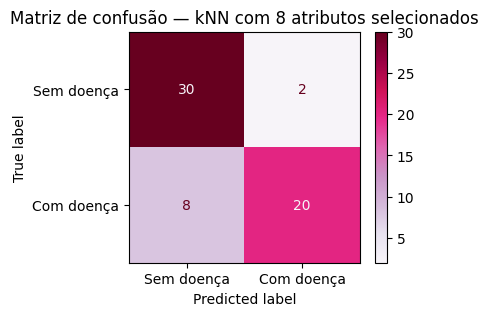

In [26]:

correlacao_com_target = (
    df_treino_final_norm
    .drop(columns=["target"])
    .corrwith(df_treino_final_norm["target"])
)

atributos_selecionados = (
    correlacao_com_target.abs()
    .sort_values(ascending=False)
    .head(8)
    .index
    .tolist()
)

print("Atributos selecionados:")
print(atributos_selecionados)
print(f"Número de atributos selecionados: {len(atributos_selecionados)}")

# Dados de treino e teste
X_treino_selecionado = df_treino_final_norm[atributos_selecionados]
y_treino = df_treino_final_norm["target"]

X_teste_selecionado = df_teste_final_norm[atributos_selecionados]
y_teste = df_teste_final_norm["target"]

# Modelo k-NN
modelo_knn_selecionado = KNeighborsClassifier(
    n_neighbors=7,
    metric="euclidean",
    weights="uniform"
)

modelo_knn_selecionado.fit(X_treino_selecionado, y_treino)

# Previsões
y_previsto_selecionado = modelo_knn_selecionado.predict(X_teste_selecionado)

# Acurácia
acuracia_selecionado = accuracy_score(y_teste, y_previsto_selecionado)
print(f"Acurácia com atributos selecionados: {acuracia_selecionado:.4f}")

# Matriz de confusão
matriz_confusao = confusion_matrix(y_teste, y_previsto_selecionado)
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(matriz_confusao,display_labels=["Sem doença", "Com doença"]).plot(cmap="PuRd", ax=ax)

plt.title(
    f"Matriz de confusão — kNN com {len(atributos_selecionados)} atributos selecionados"
)

plt.show()

<h3>Interpretação dos resultados</h3>

<p style="text-align: justify;">
O modelo k-NN treinado com os 8 atributos mais correlacionados com o target apresentou 30 verdadeiros negativos, 2 falsos positivos, 8 falsos negativos e 20 verdadeiros positivos.<br><br>

Isso significa que o modelo classificou corretamente 30 dos 32 pacientes sem doença e 20 dos 28 pacientes com doença. Por outro lado, classificou incorretamente 2 pacientes saudáveis como doentes (falsos positivos) e deixou de identificar 8 pacientes que realmente possuíam a doença (falsos negativos).<br><br>

Comparando com o modelo final treinado com todos os atributos (acurácia de 0,90), observa-se uma redução no número de falsos positivos (de 3 para 2), mas um aumento expressivo no número de falsos negativos (de 3 para 8). Em um contexto médico, esse aumento é preocupante, pois representa mais pacientes doentes que não seriam identificados pelo sistema.<br><br>

Parte dessa perda de desempenho pode estar relacionada a um efeito colateral de selecionar atributos depois da codificação one-hot, em vez de selecionar variáveis categóricas originais inteiras: dos atributos categóricos selecionados, <code>thal</code> teve apenas <code>thal_3.0</code> e <code>thal_7.0</code> mantidas (ficando de fora <code>thal_6.0</code>), <code>cp</code> (tipo de dor no peito, com 4 categorias) teve apenas <code>cp_4.0</code> mantida, <code>ca</code> teve apenas <code>ca_0.0</code>, e <code>slope</code> teve apenas <code>slope_1.0</code>. Em todos esses casos, as demais categorias da mesma variável original foram descartadas, mesmo que juntas pudessem carregar informação relevante sobre o paciente. O único atributo categórico selecionado sem essa fragmentação foi <code>exang</code>, cujas duas colunas (<code>exang_0.0</code> e <code>exang_1.0</code>) juntas já representam a variável binária original por completo.<br><br>

Embora a seleção de atributos tenha reduzido a dimensão do conjunto de dados e simplificado o modelo, parte da informação útil para a identificação da doença foi perdida. Isso sugere que atributos que individualmente apresentam menor correlação com o target ainda contribuem de forma significativa para o desempenho do k-NN quando utilizados em conjunto, e essa observação se conecta a uma limitação discutida anteriormente: a correlação de Pearson captura apenas relações lineares [4], de modo que pode estar subestimando a real importância de alguns atributos, especialmente os categóricos codificados em one-hot, cuja relação com o target não é necessariamente linear.<br><br>

Portanto, para este problema, utilizar apenas os 8 atributos mais correlacionados não trouxe nenhuma vantagem em relação ao modelo final, já que houve um aumento dos falsos negativos em relação ao modelo com todos os atributos, justamente o tipo de erro que não deve ocorrer. Isso indica que, para este dataset específico, o número de atributos gerados pelo one-hot não chegou a prejudicar o desempenho do k-NN a ponto de justificar essa redução — a hipótese da maldição da dimensionalidade, levantada anteriormente neste trabalho como motivação para este experimento, não se confirmou neste caso: o modelo completo superou o modelo reduzido tanto em acurácia quanto na identificação de pacientes com doença.
</p>

<h2>Interpretações gerais</h2>
<p style="text-align: justify;">Ao longo do trabalho, foram testados quatro fatores que influenciam o desempenho do k-NN neste problema: normalização, codificação categórica, hiperparâmetros do próprio algoritmo, e seleção de atributos. Cada experimento isolou um fator por vez, mantendo os demais fixos, o que permite atribuir as diferenças de desempenho a cada decisão específica.</p>
    <p style="text-align: justify;">
A normalização foi o fator com maior impacto isolado: a acurácia saltou de 0,68 (sem normalizar) para 0,85 (MinMax) e 0,87 (StandardScaler). Isso confirma que o k-NN, por depender de cálculo de distância, é fortemente prejudicado quando atributos como chol e age têm escalas muito diferentes entre si. Sem normalizar, esses atributos dominam a distância só por possuirem valores maiores, não pela relevância real.<br></p>
<p style="text-align: justify;">
Ao ser feita a codificação categórica, fixando o StandardScaler e hiperparâmetros (k=5, distância default), o one-hot teve acurácia de 0,8667 (28 verdadeiros negativos, 4 falsos positivos, 4 falsos negativos, 24 verdadeiros positivos), contra 0,8167 do ordinal (29, 3, 8, 20). O one-hot não só teve acurácia maior como teve bem menos falsos negativos (4 contra 8), o que é desejado em casos clínicos. Isso é consistente com o que discutimos antes: o ordinal, ao atribuir uma ordem numérica arbitrária a categorias como cp (que não têm ordem real), pode introduzir uma noção de distância irreal entre pacientes que na verdade não são tão diferentes assim, prejudicando a classificação. O custo do one-hot (mais colunas) não chegou a superar esse benefício neste caso.<br></p>
<p style="text-align: justify;">
 Hiperparâmetros (número de vizinhos, métrica de distância e peso): entre 48 combinações testadas, a distância euclidiana com k=7 e weights=uniform teve o melhor resultado (acurácia 0,90, apenas 3 falsos negativos), superando claramente manhattan e chebyshev (8 falsos negativos cada). Isso sugere que, com muitas colunas binárias geradas pelo one-hot, a euclidiana equilibra melhor a contribuição de todas as dimensões, enquanto chebyshev (que considera só a maior diferença) e manhattan tendem a perder informação nesse cenário.<br></p>
 <p style="text-align: justify;">
Seleção de atributos teve o efeito oposto ao esperado: reduzir para os 8 atributos mais correlacionados piorou o desempenho (acurácia 0,83, com 8 falsos negativos, contra 0,90 e 3 falsos negativos do modelo completo). Isso indica que a hipótese inicial, de que a dimensionalidade extra do one-hot estaria prejudicando o modelo, não se confirmou, pelo contrário, atributos com correlação individual mais fraca ainda contribuíam de forma relevante quando combinados com os demais.</p>
     <p style="text-align: justify;">
Juntando os quatro experimentos, o fator com maior impacto no desempenho foi a normalização, seguido pelos hiperparâmetros do próprio k-NN (principalmente a escolha da métrica de distância). O one-hot também se mostrou consistentemente melhor que o ordinal, tanto isoladamente quanto combinado com os melhores hiperparâmetros. Já reduzir a dimensionalidade por seleção de atributos prejudicou o modelo, contrariando a expectativa inicial. No geral, os resultados mostram que, para este dataset, vale mais a pena investir em normalizar bem os dados, escolher cuidadosamente a codificação categórica e ajustar os hiperparâmetros do k-NN do que simplificar o modelo removendo atributos.
</p>

<h2>Conclusões e principais aprendizados</h2>
<p style="text-align: justify;">Neste trabalho, tfoi treinado e avaliado modelos de k-NN para prever a presença de doença cardíaca, utilizando o dataset Heart Disease (Cleveland). Os principais aprendizados foram:

A normalização é essencial para o k-NN: normalizar os atributos numéricos elevou a acurácia de 0,68 para até 0,87, confirmando que o algoritmo é sensível a diferenças de escala entre atributos númericos.<br>
One-hot encoding superou o ordinal para os atributos categóricos deste dataset (0,87 vs 0,82 de acurácia), provavelmente por evitar relações de ordem artificiais entre categorias sem ordem real.<br>
A escolha de hiperparâmetros importa bastante: entre 48 combinações testadas, k=7 com distância euclidiana e weights=uniform teve o melhor desempenho (acurácia 0,90), com apenas 3 falsos negativos.<br>
Reduzir atributos por correlação não ajudou: usar só os 8 atributos mais correlacionados piorou o desempenho (acurácia 0,83), mostrando que atributos com correlação individual mais fraca ainda contribuem quando combinados com os de maior correlação.<br>
O modelo final superou amplamente o baseline (acurácia 0,53, que não identificava nenhum paciente doente, dado alarmante, visto que em contextos clínicos um falso negativo é muito preocupante), demonstrando que o k-NN, quando bem ajustado, aprende padrões reais a partir dos atributos clínicos.<br>

De forma geral, o trabalho reforçou que, para o k-NN, decisões de pré-processamento (normalização e encoding) têm impacto maior no desempenho do que reduzir a quantidade de atributos utilizados, e que testar hiperparâmetros de forma sistemática vale a pena, já que a diferença entre a pior e a melhor combinação testada foi de mais de 20 pontos percentuais de acurácia.</p>

<h3> Descrição do uso de Inteligência Artificial</h3>

<p align="justify"> Durante o desenvolvimento do projeto, utilizei o <strong>Claude</strong> como apoio no planejamento das etapas, na definição do target, no tratamento dos dados e na organização dos experimentos de k-NN. A ferramenta também auxiliou na interpretação dos resultados, na revisão das conclusões e também criando o documento que continha o chat da conversa original, já que não foi possível compartilha-la. </p>

<p align="justify"> O <strong>ChatGPT</strong> foi utilizado principalmente para revisar e organizar a documentação do projeto, incluindo o README. As sugestões das ferramentas foram analisadas e adaptadas pelo autor. </p>

<p align="justify"> <a href="https://chatgpt.com/share/6aaf0256-cb2c-83e9-9643-f947fd71bbf2">Registro da conversa utilizada com o Chat gpt</a> </p>

<div style="font-family: Arial, sans-serif; line-height: 1.5;">

<h2 style="color:#1F4E79;">Conversa com Claude — Revisão do Trabalho de kNN (Heart Disease)</h2>

<p><em>Este documento reúne, de forma organizada, a conversa mantida com o assistente Claude durante o desenvolvimento e revisão do trabalho de classificação com kNN (dataset Heart Disease / Cleveland).</em></p>

<hr>

<h3 style="color:#1F4E79;">1. Orientações sobre a Análise Exploratória (Passo 3) e a Métrica de Desempenho (Passo 4)</h3>

<p><strong style="color:#7030A0;">Claude:</strong> Combinado, sem código daqui pra frente — só orientação.</p>

<p><strong><em>Passo 3 — EDA</em></strong></p>
<ul>
<li>Distribuição do target: mostrar a distribuição bruta do <code>num</code> (0–4) e, ao lado, a versão binarizada (0 vs 1), deixando clara a transformação feita e o motivo.</li>
<li>Numéricos (age, trestbps, chol, thalach, oldpeak): histogramas para ver forma da distribuição, outliers e escalas diferentes — antecipando a discussão sobre normalização.</li>
<li>Categóricos (sex, cp, fbs, restecg, exang, slope, thal): gráficos de contagem por categoria, além da proporção de "com doença" dentro de cada categoria, sugerindo quais variáveis discriminam melhor o target (ex.: cp e thal costumam ser bem informativas).</li>
<li>Correlações: matriz de correlação entre numéricos e o target para relações lineares; para categóricos, usar a proporção do target por categoria, já que a correlação de Pearson não é adequada.</li>
<li>Balanceamento: verificar o percentual exato de cada classe após a binarização e o tratamento dos "?". No Cleveland completo costuma ficar perto de 54%/46% (leve desbalanceamento) — comentar isso, pois é o gancho para o Passo 4.</li>
<li>Todo gráfico precisa de eixos legendados (título dos eixos), senão é desconto certo.</li>
</ul>

<p><strong><em>Passo 4 — Métrica de desempenho</em></strong></p>
<p>O argumento mais forte não é apenas o desbalanceamento (que é leve), mas o custo assimétrico dos erros no contexto clínico:</p>
<ul>
<li>Falso negativo (dizer que a pessoa não tem doença quando tem) é o erro mais grave — a pessoa deixa de ser encaminhada para acompanhamento médico.</li>
<li>Falso positivo (dizer que tem quando não tem) gera exames extras — chato, mas bem menos grave.</li>
</ul>
<p>Isso justifica priorizar o <strong>recall</strong> (sensibilidade) da classe "com doença" como métrica de decisão entre modelos, sem abrir mão de olhar a precisão e reportar a matriz de confusão. A acurácia pode aparecer como referência geral, mas não deve ser o critério principal de escolha. Complementarmente, pode-se usar AUC-ROC para avaliar a separação entre as classes independente de um único threshold.</p>

<hr>

<h3 style="color:#1F4E79;">2. Dúvida sobre a ordem dos gráficos na EDA</h3>

<p><strong style="color:#1F4E79;">Aluno(a):</strong> Eu já fiz esses passos, só gostaria de saber se fica muito estranho eu fazer os gráficos dos dados categóricos e numéricos, definir o target e depois fazer outro gráfico relacionando o target reformulado com os dados numéricos?</p>

<p><strong style="color:#7030A0;">Claude:</strong> Não fica estranho — é uma sequência natural e recomendável:</p>
<ol>
<li>Mostrar os dados "crus" primeiro, ajudando o leitor a entender a base antes de qualquer transformação;</li>
<li>Definir e justificar a reformulação do target (binarização), como decisão de modelagem própria;</li>
<li>Só então relacionar os numéricos com o target já reformulado, respondendo à pergunta central do problema de classificação.</li>
</ol>
<p>Essa separação evidencia o raciocínio por trás de cada decisão, exatamente o tipo de sequência que o enunciado valoriza como "guiar o leitor".</p>
<p><strong>Sugestão adicional:</strong> no segundo gráfico (numéricos vs. target binarizado), evitar repetir os mesmos histogramas de antes — preferir boxplots ou histogramas separados por classe (target = 0 vs 1) para cada atributo numérico, tornando a análise um aprofundamento e não uma repetição.</p>

<hr>

<h3 style="color:#1F4E79;">3. Redação sobre outliers e conexão com a normalização</h3>

<p>Sugestão de texto elaborada com o Claude para descrever os outliers observados e conectar essa observação com a etapa de normalização discutida mais adiante no notebook:</p>

<blockquote style="border-left: 3px solid #7030A0; padding-left: 12px; color:#333;">
"Tanto no histograma quanto no boxplot, é possível observar a presença de outliers em algumas variáveis — valores que se afastam consideravelmente da tendência central dos dados, como os pontos isolados observados em chol, trestbps e oldpeak. Esses valores extremos podem impactar o desempenho do k-NN, já que o algoritmo se baseia no cálculo de distância entre os pacientes: um único atributo com valor muito distante da média pode distorcer a distância calculada, mesmo que os demais atributos daquele paciente sejam típicos. Essa observação reforça a importância da normalização, discutida mais adiante neste trabalho."
</blockquote>

<p><strong>Observações do Claude sobre essa sugestão:</strong></p>
<ul>
<li>Citar as variáveis específicas onde de fato apareceram outliers nos gráficos reais (chol, trestbps e oldpeak como exemplo).</li>
<li>Evitar a palavra "média" no sentido de "o outlier não é a média" — o mais correto é dizer que o valor "se afasta da tendência central".</li>
<li>A conexão com o kNN já prepara a ponte com a seção de normalização, algo valorizado pelo enunciado como forma de "guiar o leitor".</li>
</ul>

<hr>

<h3 style="color:#1F4E79;">4. Revisão final do notebook: checklist de exigências e pontos extras</h3>

<p><strong style="color:#1F4E79;">Aluno(a):</strong> Veja se agora melhorou e veja se eu cumpri todas as exigências do "cubo gelatinoso" e se fiz ao menos 3 pontos "extras".</p>

<p><strong>Correções já feitas desde a revisão anterior:</strong></p>
<ul>
<li>Placeholder da Célula 7 preenchido corretamente: ca (4 valores nulos) e thal (2 valores nulos), conferido na saída do <code>isna().sum()</code>.</li>
<li>Cabeçalhos das Células 11/14 corrigidos: "Describe dos dados categóricos" e "numéricos" agora mostram os describes corretos.</li>
<li>Célula 33 (outliers): texto específico e conectado com a normalização discutida mais adiante.</li>
<li>Célula 74 (célula vazia) foi removida.</li>
</ul>

<p><strong>Ainda crítico:</strong> a seção "Descrição do uso de IA neste trabalho" continua ausente no notebook — só está pendente no README. É a exigência mais importante que falta resolver, pois é obrigatória pelo enunciado.</p>

<p><strong>Ainda pendente da revisão anterior:</strong></p>
<ul>
<li>Célula 40: aspa dupla sobrando no HTML.</li>
<li>Célula 52: tag mal fechada — falta a barra no fechamento do <code>&lt;h2&gt;</code>.</li>
<li>Célula 27: erros de digitação ("seráusada", "aos total de exemplo usados", "considerar a base de dados está relativamente balanceadas").</li>
<li>Célula 78: célula de código vazia sobrando no final.</li>
<li>Referências: [6] (GeeksforGeeks) nunca é citada no texto; referência do Seaborn sem número ([9]).</li>
</ul>

<p><strong>Checklist de exigências do Cubo Gelatinoso:</strong></p>
<table style="border-collapse: collapse; width: 100%;">
<tr style="background:#1F4E79; color:white;">
<th style="border:1px solid #ccc; padding:6px; text-align:left;">Exigência</th>
<th style="border:1px solid #ccc; padding:6px; text-align:left;">Status</th>
</tr>
<tr><td style="border:1px solid #ccc; padding:6px;">≥5 atributos, ≥1 categórico</td><td style="border:1px solid #ccc; padding:6px;">✅ 13 atributos, vários categóricos</td></tr>
<tr><td style="border:1px solid #ccc; padding:6px;">≥1 target</td><td style="border:1px solid #ccc; padding:6px;">✅ binarizado e justificado</td></tr>
<tr><td style="border:1px solid #ccc; padding:6px;">≥150 exemplos</td><td style="border:1px solid #ccc; padding:6px;">✅ 297 após remoção de nulos</td></tr>
<tr><td style="border:1px solid #ccc; padding:6px;">Dados não sintéticos</td><td style="border:1px solid #ccc; padding:6px;">✅</td></tr>
<tr><td style="border:1px solid #ccc; padding:6px;">Notebook Jupyter</td><td style="border:1px solid #ccc; padding:6px;">✅</td></tr>
<tr><td style="border:1px solid #ccc; padding:6px;">scikit-learn para kNN</td><td style="border:1px solid #ccc; padding:6px;">✅</td></tr>
<tr><td style="border:1px solid #ccc; padding:6px;">≥10 combinações de hiperparâmetros</td><td style="border:1px solid #ccc; padding:6px;">✅ 48 testadas</td></tr>
<tr><td style="border:1px solid #ccc; padding:6px;">Métrica justificada</td><td style="border:1px solid #ccc; padding:6px;">✅</td></tr>
<tr><td style="border:1px solid #ccc; padding:6px;">Resultados gráficos</td><td style="border:1px solid #ccc; padding:6px;">✅</td></tr>
<tr><td style="border:1px solid #ccc; padding:6px;">"Conclusões e principais aprendizados"</td><td style="border:1px solid #ccc; padding:6px;">✅ presente</td></tr>
<tr><td style="border:1px solid #ccc; padding:6px;">"Descrição do uso de IA"</td><td style="border:1px solid #ccc; padding:6px;">❌ ausente</td></tr>
<tr><td style="border:1px solid #ccc; padding:6px;">Código roda sem erro (ordem)</td><td style="border:1px solid #ccc; padding:6px;">✅ confirmado, 27 células sequenciais, zero erros</td></tr>
<tr><td style="border:1px solid #ccc; padding:6px;">Referências</td><td style="border:1px solid #ccc; padding:6px;">⚠️ presentes, mas com uma citação órfã e uma sem número</td></tr>
</table>

<p><strong>Pontos complementares (mínimo 3, máximo vale 3 pontos no total):</strong></p>
<p>Todos os 5 itens listados no enunciado foram cumpridos:</p>
<ul>
<li>Boa EDA + comparação com baseline</li>
<li>Desempenho com/sem normalização, testando diferentes formas (sem normalizar, MinMax, StandardScaler)</li>
<li>Variação do número de vizinhos (k de 1 a 21)</li>
<li>Variação da função de distância, com 3 funções diferentes (euclidean, manhattan, chebyshev)</li>
<li>Variação da estratégia de codificação categórica (one-hot vs. ordinal)</li>
</ul>
<p>O teto de pontuação complementar já foi garantido — e ainda há um experimento extra de seleção de atributos por correlação, mostrando profundidade adicional além do exigido.</p>

<p><strong>Resumo final:</strong> o trabalho está muito bem estruturado, superando os pontos complementares exigidos. O único bloqueio real para a entrega é escrever a seção de uso de IA — o restante são ajustes pequenos de digitação e HTML que não afetam a execução, mas valem a pena corrigir para uma revisão mais polida.

</div>

<h2>Referêcias bibliográficas</h2>
<p style="text-align: justify;">[1] Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1988). Heart Disease [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P4X</p>

[2] CETIN, Ruveyda Kardel. The importance of splitting datasets into training, validation and test sets. Medium, 2021. Disponível em: https://ruveydakardelcetin.medium.com/the-importance-of-splitting-datasets-into-training-validation-and-test-sets-417caaeae91d. Acesso em: 19 set. 2026.

[3] CHEBYSHEV distance. In: WIKIPEDIA: the free encyclopedia. Disponível em: https://en.wikipedia.org/wiki/Chebyshev_distance. Acesso em: 19 set. 2026.

[4] COEFICIENTE de correlação de Pearson. In: WIKIPÉDIA: a enciclopédia livre. Disponível em: https://pt.wikipedia.org/wiki/Coeficiente_de_correla%C3%A7%C3%A3o_de_Pearson. Acesso em: 19 set. 2026.

[5] DE SOUZA, Emanuel. Entendendo o que é matriz de confusão com Python. Medium — Data Hackers, 2019. Disponível em: https://medium.com/data-hackers/entendendo-o-que-%C3%A9-matriz-de-confus%C3%A3o-com-python-114e683ec509. Acesso em: 19 set. 2026.

[6] GEEKSFORGEEKS. Python Pandas DataFrame corr(). Disponível em: https://www.geeksforgeeks.org/pandas/python-pandas-dataframe-corr/. Acesso em: 19 set. 2026.

[7] GOOGLE. One-hot encoding. In: Machine Learning Crash Course. Google for Developers, [s.d.]. Disponível em: https://developers.google.com/machine-learning/crash-course/categorical-data/one-hot-encoding?hl=pt-. Acesso em: 19 set. 2026.

[8] JUNIOR, Edson. Principais métricas de classificação de modelos em Machine Learning. Medium — Data Hackers, [s.d.]. Disponível em: https://medium.com/data-hackers/principais-m%C3%A9tricas-de-classifica%C3%A7%C3%A3o-de-modelos-em-machine-learning-94eeb4b40ea9. Acesso em: 19 set. 2026.

SEABORN. Visualizing statistical relationships (relational.html). Disponível em: https://seaborn.pydata.org/tutorial/relational.html. Acesso em: 19 set. 2026.

<h3>Apêndice</h3>
<p style="text-align: justify;">O código abaixo testa todas as combinações entre normalização, encoding e número de vizinhos de uma vez, treinando um k-NN para cada combinação e comparando as acurácias obtidas. Ele não faz parte da análise principal deste trabalho , serviu apenas como uma checagem posterior, para confirmar se a combinação escolhida como modelo final (StandardScaler + one-hot + k=7) permanece entre as melhores quando todos os fatores são avaliados juntos, e não apenas isoladamente como nas seções anteriores.</p>

In [27]:

from sklearn.metrics import accuracy_score

# todas as versões de dados já montadas (normalização x encoding)
versoes_dados = {
    ("Sem normalizar", "One-hot"): (df_treino_final, df_teste_final),
    ("MinMax", "One-hot"): (df_treino_final_minmax, df_teste_final_minmax),
    ("StandardScaler", "One-hot"): (df_treino_final_norm, df_teste_final_norm),
    ("StandardScaler", "Ordinal"): (df_treino_final_ordinal_norm, df_teste_final_ordinal_norm),
}

valores_k = [1, 3, 5, 7, 9, 11, 15, 21]


resultados = []

for (normalizacao, encoding), (treino, teste) in versoes_dados.items():
    X_treino = treino.drop(columns=["target"])
    y_treino = treino["target"]
    X_teste = teste.drop(columns=["target"])
    y_teste = teste["target"]

    for k in valores_k:
        modelo_knn = KNeighborsClassifier(n_neighbors=k)
        modelo_knn.fit(X_treino, y_treino)
        y_previsto = modelo_knn.predict(X_teste)

        resultados.append({
            "normalizacao": normalizacao,
            "encoding": encoding,
            "n_neighbors": k,
            "acuracia": accuracy_score(y_teste, y_previsto),
        })

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values("acuracia", ascending=False)
df_resultados

,normalizacao,encoding,n_neighbors,acuracia
19,StandardScaler,One-hot,7,0.900000
20,StandardScaler,One-hot,9,0.866667
16,StandardScaler,One-hot,1,0.866667
18,StandardScaler,One-hot,5,0.866667
21,StandardScaler,One-hot,11,0.866667
13,MinMax,One-hot,11,0.850000
10,MinMax,One-hot,5,0.850000
14,MinMax,One-hot,15,0.850000
31,StandardScaler,Ordinal,21,0.850000
22,StandardScaler,One-hot,15,0.850000


Também foi feita a matriz de confusão do modelo baseline usando os dados normalizados para confirmar que realmente os dados normalizados não impactam no baseline

Acurácia do baseline: 0.5333333333333333


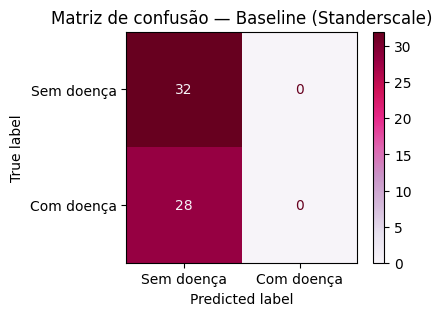

In [31]:
X_treino = df_treino_final_norm.drop(columns=["target"])
y_treino = df_treino_final_norm["target"]

X_teste = df_teste_final.drop(columns=["target"])
y_teste = df_teste_final["target"]

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_treino, y_treino)

y_previsto_baseline = baseline.predict(X_teste)

acuracia_baseline = accuracy_score(y_teste, y_previsto_baseline)
print(f"Acurácia do baseline: {acuracia_baseline:}")
fig, ax = plt.subplots(figsize=(4, 3))
matriz_confusao = confusion_matrix(y_teste, y_previsto_baseline)
ConfusionMatrixDisplay(matriz_confusao, display_labels=["Sem doença", "Com doença"]).plot(cmap="PuRd", ax=ax)
plt.title("Matriz de confusão — Baseline (Standerscale)")
plt.show()

Acurácia do baseline: 0.5333333333333333


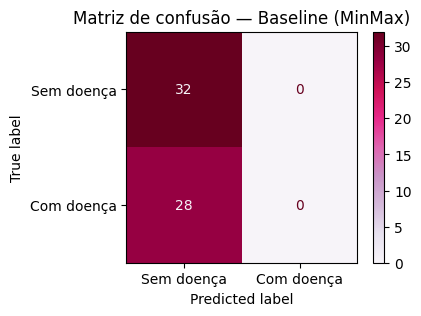

In [32]:
X_treino = df_treino_final_minmax.drop(columns=["target"])
y_treino = df_treino_final_minmax["target"]

X_teste = df_teste_final.drop(columns=["target"])
y_teste = df_teste_final["target"]

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_treino, y_treino)

y_previsto_baseline = baseline.predict(X_teste)

acuracia_baseline = accuracy_score(y_teste, y_previsto_baseline)
print(f"Acurácia do baseline: {acuracia_baseline:}")
fig, ax = plt.subplots(figsize=(4, 3))
matriz_confusao = confusion_matrix(y_teste, y_previsto_baseline)
ConfusionMatrixDisplay(matriz_confusao, display_labels=["Sem doença", "Com doença"]).plot(cmap="PuRd", ax=ax)
plt.title("Matriz de confusão — Baseline (MinMax)")
plt.show()